In [56]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")

# Cargar datos procesados
era5  = xr.open_dataset("../datos/procesados/era5_procesado.nc")
oisst = xr.open_dataset("../datos/procesados/oisst_procesado.nc")
mld   = xr.open_dataset("../datos/procesados/mld_procesado.nc")

print("ERA5:", era5)
print("OISST:", oisst)
print("MLD:", mld)

ERA5: <xarray.Dataset> Size: 308MB
Dimensions:    (time: 16071, latitude: 33, longitude: 29)
Coordinates:
  * time       (time) datetime64[ns] 129kB 1980-01-01 1980-01-02 ... 2023-12-31
  * latitude   (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 232B -82.0 -81.75 -81.5 ... -75.25 -75.0
Data variables:
    t2m        (time, latitude, longitude) float32 62MB ...
    q          (time, latitude, longitude) float32 62MB ...
    wspd       (time, latitude, longitude) float32 62MB ...
    sw         (time, latitude, longitude) float32 62MB ...
    lw         (time, latitude, longitude) float32 62MB ...
OISST: <xarray.Dataset> Size: 59MB
Dimensions:    (time: 15340, latitude: 33, longitude: 29)
Coordinates:
  * time       (time) datetime64[ns] 123kB 1982-01-01 1982-01-02 ... 2023-12-31
  * latitude   (latitude) float32 132B 0.125 0.375 0.625 ... 7.625 7.875 8.125
  * longitude  (longitude) float32 116B -82.12 -81.88 -81.62 ... -75.38 -75.12

In [57]:
# Pixel de prueba: 4N, 80W
lat0, lon0 = 4.0, -80.0

t2m_px  = era5["t2m"].sel(latitude=lat0,  longitude=lon0, method="nearest").values
q_px    = era5["q"].sel(latitude=lat0,    longitude=lon0, method="nearest").values
wspd_px = era5["wspd"].sel(latitude=lat0, longitude=lon0, method="nearest").values
sw_px   = era5["sw"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
lw_px   = era5["lw"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
h_clim  = mld["mld"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
sst_obs = oisst["sst"].sel(latitude=lat0, longitude=lon0, method="nearest").values

# Recortar ERA5 al periodo OISST (1982-2023)
idx_ini = np.where(era5.time.values == np.datetime64("1982-01-01"))[0][0]
t2m_px  = t2m_px[idx_ini:]
q_px    = q_px[idx_ini:]
wspd_px = wspd_px[idx_ini:]
sw_px   = sw_px[idx_ini:]
lw_px   = lw_px[idx_ini:]

print(f"SST inicial observada: {sst_obs[0]:.2f} °C")
print(f"h_clim 12 meses: {h_clim.round(1)}")
print(f"Dias de forzamiento: {len(t2m_px)}")
print(f"t2m  rango: {t2m_px.min():.2f} -- {t2m_px.max():.2f} °C")
print(f"sw   rango: {sw_px.min():.2f} -- {sw_px.max():.2f} W/m2")
print(f"wspd rango: {wspd_px.min():.2f} -- {wspd_px.max():.2f} m/s")


SST inicial observada: 25.43 °C
h_clim 12 meses: [13.5 10.8 11.3 12.4 15.8 17.  17.1 17.  19.2 19.6 17.1 14.9]
Dias de forzamiento: 15340
t2m  rango: 21.67 -- 28.80 °C
sw   rango: 0.28 -- 62.47 W/m2
wspd rango: 0.06 -- 12.77 m/s


In [58]:
# Constantes fisicas
RHO_W   = 1025.0
CP_W    = 3994.0
RHO_A   = 1.2
CP_A    = 1005.0
EPSILON = 0.97
SIGMA   = 5.67e-8

def flujos_coare(sst, t2m, q, wspd):
    e_sat = 6.112 * np.exp(17.67 * sst / (sst + 243.5))
    q_sat = 0.622 * e_sat / (1013.25 - 0.378 * e_sat)
    dq    = q_sat - q
    dt    = sst - t2m
    wspd  = np.maximum(wspd, 0.5)
    Cd    = 1e-3 * (0.61 + 0.063 * wspd)
    Ch    = 1.3e-3
    Ce    = 1.15e-3
    Lv    = 2.5e6
    Ql    = RHO_A * Lv   * Ce * wspd * dq
    Qs    = RHO_A * CP_A * Ch * wspd * dt
    tau   = RHO_A * Cd * wspd**2
    return Ql, Qs, tau

def flujo_neto(sst, sw, lw, Ql, Qs):
    albedo = 0.06
    Qsw    = (1 - albedo) * sw
    sst_k  = sst + 273.15
    Qlw    = lw - EPSILON * SIGMA * sst_k**4
    Qnet   = Qsw + Qlw - Ql - Qs
    return Qnet, Qsw, Qlw

def correr_modelo(t2m, q, wspd, sw, lw, h_clim, sst_ini, tiempo, dt=86400.0):
    n       = len(t2m)
    sst_sim = np.full(n, np.nan)
    qnet    = np.full(n, np.nan)
    sst     = sst_ini

    for i in range(n):
        mes = tiempo[i].astype("datetime64[M]").astype(int) % 12  # 0-11
        h   = h_clim[mes]
        Ql, Qs, tau      = flujos_coare(sst, t2m[i], q[i], wspd[i])
        Qnet, Qsw, Qlw   = flujo_neto(sst, sw[i], lw[i], Ql, Qs)
        dT               = (Qnet * dt) / (RHO_W * CP_W * h)
        T_sub            = sst - 1.0
        we               = np.maximum(-Qnet, 0.0) / (RHO_W * CP_W * max(sst - T_sub, 0.1))
        Q_ent            = RHO_W * CP_W * we * (sst - T_sub)
        dT              -= (Q_ent * dt) / (RHO_W * CP_W * h)
        sst             += dT
        sst_sim[i]       = sst
        qnet[i]          = Qnet

    return sst_sim, qnet

print("Funciones definidas.")

Funciones definidas.


In [59]:
# Diagnostico balance energetico con datos corregidos
print("=== Diagnostico balance energetico (promedio primer año) ===")
Ql, Qs, tau = flujos_coare(sst_obs[:365].mean(), t2m_px[:365].mean(),
                            q_px[:365].mean(), wspd_px[:365].mean())
Qnet, Qsw, Qlw = flujo_neto(sst_obs[:365].mean(), sw_px[:365].mean(),
                             lw_px[:365].mean(), Ql, Qs)

sst_k = sst_obs[:365].mean() + 273.15
Qlw_emitido = EPSILON * SIGMA * sst_k**4

print(f"SW descendente medio:     {sw_px[:365].mean():.1f} W/m2")
print(f"LW descendente medio:     {lw_px[:365].mean():.1f} W/m2")
print(f"LW emitido por oceano:    {Qlw_emitido:.1f} W/m2")
print(f"LW neto:                  {Qlw:.1f} W/m2")
print(f"SW neto:                  {Qsw:.1f} W/m2")
print(f"Calor latente:            {Ql:.1f} W/m2")
print(f"Calor sensible:           {Qs:.1f} W/m2")
print(f"Qnet total:               {Qnet:.1f} W/m2")

=== Diagnostico balance energetico (promedio primer año) ===
SW descendente medio:     19.0 W/m2
LW descendente medio:     421.0 W/m2
LW emitido por oceano:    445.1 W/m2
LW neto:                  -24.1 W/m2
SW neto:                  17.9 W/m2
Calor latente:            54.9 W/m2
Calor sensible:           7.4 W/m2
Qnet total:               -68.5 W/m2


In [60]:
# Verificar factor de escala necesario
# SW medio diario tipico tropical: ~180-220 W/m2 (Wild et al 2013)
# Nuestro SW medio: 19 W/m2
# Factor necesario: ~10

print(f"SW medio actual:          {sw_px[:365].mean():.1f} W/m2")
print(f"Factor x2:                {sw_px[:365].mean()*2:.1f} W/m2")
print(f"Factor x pi/2:            {sw_px[:365].mean()*np.pi/2:.1f} W/m2")
print(f"Factor x10:               {sw_px[:365].mean()*10:.1f} W/m2")

# Revisar el atributo de la variable en el archivo
print("\nAtributos SW en era5_procesado:")
print(era5["sw"].attrs)

SW medio actual:          19.0 W/m2
Factor x2:                38.0 W/m2
Factor x pi/2:            29.8 W/m2
Factor x10:               189.9 W/m2

Atributos SW en era5_procesado:
{'GRIB_paramId': np.int64(235035), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(957), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'avg', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(29), 'GRIB_Ny': np.int64(33), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'avg_sdswrf', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(8.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfFirstGridPointI

In [61]:
import xarray as xr
ds = xr.open_dataset("../datos/ERA5/era5_surface_solar_radiation_downwards_1980.nc")
print(ds.valid_time.values[:10])
print(ds["ssrd"].values[:10, 16, 14])

['1980-01-01T00:00:00.000000000' '1980-01-01T03:00:00.000000000'
 '1980-01-01T06:00:00.000000000' '1980-01-01T09:00:00.000000000'
 '1980-01-01T12:00:00.000000000' '1980-01-01T15:00:00.000000000'
 '1980-01-01T18:00:00.000000000' '1980-01-01T21:00:00.000000000'
 '1980-01-02T00:00:00.000000000' '1980-01-02T03:00:00.000000000']
[3.392000e+03 0.000000e+00 0.000000e+00 0.000000e+00 4.953600e+04
 1.265472e+06 9.541120e+05 5.864320e+05 1.536000e+03 0.000000e+00]


In [62]:
# Calcular SW diario como maximo del acumulado de cada dia
# (el maximo ocurre al final del dia antes del reinicio nocturno)
vals_dia1 = ds["ssrd"].values[:8, 16, 14]
print("Acumulados dia 1 (J/m2):", vals_dia1.round(0))
print("Maximo (= total del dia):", vals_dia1.max().round(0))
print("Flujo medio diario (W/m2):", (vals_dia1.max() / 86400).round(1))

vals_dia2 = ds["ssrd"].values[8:16, 16, 14]
print("\nAcumulados dia 2 (J/m2):", vals_dia2.round(0))
print("Maximo:", vals_dia2.max().round(0))
print("Flujo medio diario (W/m2):", (vals_dia2.max() / 86400).round(1))

Acumulados dia 1 (J/m2): [3.392000e+03 0.000000e+00 0.000000e+00 0.000000e+00 4.953600e+04
 1.265472e+06 9.541120e+05 5.864320e+05]
Maximo (= total del dia): 1.265472e+06
Flujo medio diario (W/m2): 14.6

Acumulados dia 2 (J/m2): [  1536.      0.      0.      0.  12736. 401472. 492032. 792768.]
Maximo: 792768.0
Flujo medio diario (W/m2): 9.2


In [63]:
# Verificar patron de reinicio
print("Dia 1 completo con timestamps:")
for i in range(8):
    t = ds.valid_time.values[i]
    v = ds["ssrd"].values[i, 16, 14]
    print(f"  {t}  {v:.0f} J/m2")

print("\nDia 2:")
for i in range(8, 16):
    t = ds.valid_time.values[i]
    v = ds["ssrd"].values[i, 16, 14]
    print(f"  {t}  {v:.0f} J/m2")

Dia 1 completo con timestamps:
  1980-01-01T00:00:00.000000000  3392 J/m2
  1980-01-01T03:00:00.000000000  0 J/m2
  1980-01-01T06:00:00.000000000  0 J/m2
  1980-01-01T09:00:00.000000000  0 J/m2
  1980-01-01T12:00:00.000000000  49536 J/m2
  1980-01-01T15:00:00.000000000  1265472 J/m2
  1980-01-01T18:00:00.000000000  954112 J/m2
  1980-01-01T21:00:00.000000000  586432 J/m2

Dia 2:
  1980-01-02T00:00:00.000000000  1536 J/m2
  1980-01-02T03:00:00.000000000  0 J/m2
  1980-01-02T06:00:00.000000000  0 J/m2
  1980-01-02T09:00:00.000000000  0 J/m2
  1980-01-02T12:00:00.000000000  12736 J/m2
  1980-01-02T15:00:00.000000000  401472 J/m2
  1980-01-02T18:00:00.000000000  492032 J/m2
  1980-01-02T21:00:00.000000000  792768 J/m2


In [64]:
# El timestep de las 12:00 UTC = acumulado de 24h desde 12:00 UTC dia anterior
# = flujo diario completo
sw_12 = ds["ssrd"].sel(valid_time=ds.valid_time[ds.valid_time.dt.hour == 12]).values[:, 16, 14]
print("SW a las 12:00 UTC primeros 5 dias (J/m2):", sw_12[:5].round(0))
print("Flujo diario (W/m2):", (sw_12[:5] / 86400).round(1))

lw_ds = xr.open_dataset("../datos/ERA5/era5_surface_thermal_radiation_downwards_1980.nc")
lw_12 = lw_ds["strd"].sel(valid_time=lw_ds.valid_time[lw_ds.valid_time.dt.hour == 12]).values[:, 16, 14]
print("\nLW a las 12:00 UTC primeros 5 dias (J/m2):", lw_12[:5].round(0))
print("Flujo diario (W/m2):", (lw_12[:5] / 86400).round(1))

SW a las 12:00 UTC primeros 5 dias (J/m2): [49536. 12736. 21056. 44224. 47424.]
Flujo diario (W/m2): [0.6 0.1 0.2 0.5 0.5]

LW a las 12:00 UTC primeros 5 dias (J/m2): [1.531035e+06 1.543386e+06 1.540483e+06 1.528616e+06 1.511155e+06]
Flujo diario (W/m2): [17.7 17.9 17.8 17.7 17.5]


In [65]:
# El avg_sdswrf que descargamos: 19 W/m2 medio
# Comparar con CERES SYN1deg que ya usamos en proyecto 3
# En el tropico el SW descendente medio es ~185-220 W/m2

# Revisar si hay un step range en los atributos
sw_avg = xr.open_dataset("../datos/ERA5/era5_msdwswrf_1980_2023.nc")
print("GRIB_stepRange:", sw_avg["avg_sdswrf"].attrs.get("GRIB_stepRange", "no attr"))
print("GRIB_startStep:", sw_avg["avg_sdswrf"].attrs.get("GRIB_startStep", "no attr"))
print("GRIB_endStep:",   sw_avg["avg_sdswrf"].attrs.get("GRIB_endStep",   "no attr"))
print("GRIB_stepType:",  sw_avg["avg_sdswrf"].attrs.get("GRIB_stepType",  "no attr"))
print()
# Valor a las 12:00 UTC para enero 1980, pixel central
print("Valor 1980-01-01:", float(sw_avg["avg_sdswrf"].isel(valid_time=0, latitude=16, longitude=14)))

GRIB_stepRange: no attr
GRIB_startStep: no attr
GRIB_endStep: no attr
GRIB_stepType: avg

Valor 1980-01-01: 13.75


In [66]:
# SW diario = acumulado 21:00 UTC - acumulado 00:00 UTC del mismo dia
# Cubre 21 horas, incluyendo todas las horas de luz en UTC-5

dia1_00 = ds["ssrd"].values[0, 16, 14]   # 00:00 UTC
dia1_21 = ds["ssrd"].values[7, 16, 14]   # 21:00 UTC
dia2_00 = ds["ssrd"].values[8, 16, 14]   # 00:00 UTC dia siguiente

print(f"00:00 UTC dia 1: {dia1_00:.0f} J/m2")
print(f"21:00 UTC dia 1: {dia1_21:.0f} J/m2")
print(f"00:00 UTC dia 2: {dia2_00:.0f} J/m2")
print()
print(f"Diferencia 21:00 - 00:00 dia 1: {dia1_21 - dia1_00:.0f} J/m2")
print(f"Flujo medio diario: {(dia1_21 - dia1_00) / 86400:.1f} W/m2")
print()
# Verificar con dia 2
dia2_21 = ds["ssrd"].values[15, 16, 14]
print(f"Diferencia dia 2: {dia2_21 - dia2_00:.0f} J/m2")
print(f"Flujo medio diario dia 2: {(dia2_21 - dia2_00) / 86400:.1f} W/m2")

00:00 UTC dia 1: 3392 J/m2
21:00 UTC dia 1: 586432 J/m2
00:00 UTC dia 2: 1536 J/m2

Diferencia 21:00 - 00:00 dia 1: 583040 J/m2
Flujo medio diario: 6.7 W/m2

Diferencia dia 2: 791232 J/m2
Flujo medio diario dia 2: 9.2 W/m2


In [67]:
# Cargar CERES del proyecto 3 para comparar SW descendente
from pathlib import Path
import glob
ceres_dir = Path.cwd().parent.parent / 'proyecto 3' / 'datos' / 'ceres' / 'raw'
ceres_files = sorted(glob.glob(str(ceres_dir / '*.nc')))
print('Directorio CERES:', ceres_dir)
print("Archivos CERES disponibles:", len(ceres_files))
if ceres_files:
    ds_ceres = xr.open_dataset(ceres_files[0])
    print(ds_ceres)
else:
    print('No se encontraron archivos .nc en', ceres_dir)

Directorio CERES: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/ceres/raw
Archivos CERES disponibles: 3
<xarray.Dataset> Size: 2GB
Dimensions:                              (time: 1466, lat: 180, lon: 360)
Coordinates:
  * time                                 (time) datetime64[ns] 12kB 2001-01-0...
  * lat                                  (lat) float32 720B -89.5 -88.5 ... 89.5
  * lon                                  (lon) float32 1kB 0.5 1.5 ... 359.5
Data variables:
    toa_net_all_daily                    (time, lat, lon) float32 380MB ...
    adj_atmos_sw_up_all_surface_daily    (time, lat, lon) float32 380MB ...
    adj_atmos_sw_down_all_surface_daily  (time, lat, lon) float32 380MB ...
    adj_atmos_lw_up_all_surface_daily    (time, lat, lon) float32 380MB ...
    adj_atmos_lw_down_all_surface_daily  (time, lat, lon) float32 380MB ...
Attributes:
    title:        CERES SYN1deg Daily data
    institution:  NASA Langley Research Center
    Conventions

In [68]:
# SW descendente superficie en CERES para region Pacifico colombiano
sw_ceres = ds_ceres["adj_atmos_sw_down_all_surface_daily"].sel(
    lat=slice(0, 8),
    lon=slice(278, 285)  # 0-360: 278-285 = 82-75W
).mean(dim=["lat", "lon"])

print(f"CERES SW descendente medio 2001-2009: {float(sw_ceres.mean()):.1f} W/m2")
print(f"CERES SW descendente min/max: {float(sw_ceres.min()):.1f} -- {float(sw_ceres.max()):.1f} W/m2")

# Comparar con ERA5 para el mismo periodo
era5_sw_periodo = era5["sw"].sel(
    time=slice("2001-01-01", "2009-12-31")
).mean(dim=["latitude", "longitude"])

print(f"\nERA5 SW medio 2001-2009: {float(era5_sw_periodo.mean()):.1f} W/m2")
print(f"Factor de escala necesario: {float(sw_ceres.mean()) / float(era5_sw_periodo.mean()):.1f}")

CERES SW descendente medio 2001-2009: 178.2 W/m2
CERES SW descendente min/max: 89.5 -- 262.2 W/m2

ERA5 SW medio 2001-2009: 25.8 W/m2
Factor de escala necesario: 6.9


In [69]:
# Verificar estabilidad del factor por año usando CERES 2001-2009
for year in range(2001, 2010):
    sw_c = ds_ceres["adj_atmos_sw_down_all_surface_daily"].sel(
        lat=slice(0, 8), lon=slice(278, 285),
        time=slice(f"{year}-01-01", f"{year}-12-31")
    ).mean(dim=["lat", "lon"])
    
    sw_e = era5["sw"].sel(
        time=slice(f"{year}-01-01", f"{year}-12-31")
    ).mean(dim=["latitude", "longitude"])
    
    factor = float(sw_c.mean()) / float(sw_e.mean())
    print(f"{year}: CERES={float(sw_c.mean()):.1f}  ERA5={float(sw_e.mean()):.1f}  factor={factor:.2f}")

2001: CERES=178.6  ERA5=25.8  factor=6.91
2002: CERES=178.7  ERA5=26.5  factor=6.74
2003: CERES=175.9  ERA5=25.4  factor=6.93
2004: CERES=179.5  ERA5=26.1  factor=6.88
2005: CERES=174.3  ERA5=25.6  factor=6.81
2006: CERES=nan  ERA5=25.9  factor=nan
2007: CERES=nan  ERA5=25.3  factor=nan
2008: CERES=nan  ERA5=25.6  factor=nan
2009: CERES=nan  ERA5=26.4  factor=nan


In [70]:
SW_FACTOR = 6.85

# Verificar balance con SW corregido
sw_corregido = sw_px[:365].mean() * SW_FACTOR
print(f"SW corregido medio: {sw_corregido:.1f} W/m2")

Ql, Qs, tau = flujos_coare(sst_obs[:365].mean(), t2m_px[:365].mean(),
                            q_px[:365].mean(), wspd_px[:365].mean())
Qnet, Qsw, Qlw = flujo_neto(sst_obs[:365].mean(), 
                             sw_px[:365].mean() * SW_FACTOR,
                             lw_px[:365].mean(), Ql, Qs)

sst_k = sst_obs[:365].mean() + 273.15
Qlw_emitido = EPSILON * SIGMA * sst_k**4

print(f"SW descendente medio:     {sw_px[:365].mean() * SW_FACTOR:.1f} W/m2")
print(f"LW descendente medio:     {lw_px[:365].mean():.1f} W/m2")
print(f"LW emitido por oceano:    {Qlw_emitido:.1f} W/m2")
print(f"LW neto:                  {Qlw:.1f} W/m2")
print(f"SW neto:                  {Qsw:.1f} W/m2")
print(f"Calor latente:            {Ql:.1f} W/m2")
print(f"Calor sensible:           {Qs:.1f} W/m2")
print(f"Qnet total:               {Qnet:.1f} W/m2")

SW corregido medio: 130.1 W/m2
SW descendente medio:     130.1 W/m2
LW descendente medio:     421.0 W/m2
LW emitido por oceano:    445.1 W/m2
LW neto:                  -24.1 W/m2
SW neto:                  122.3 W/m2
Calor latente:            54.9 W/m2
Calor sensible:           7.4 W/m2
Qnet total:               35.9 W/m2


In [71]:
sst_sim, qnet = correr_modelo(
    t2m_px, q_px, wspd_px,
    sw_px * SW_FACTOR,
    lw_px,
    h_clim, sst_ini=sst_obs[0],
    tiempo=oisst.time.values
)

print(f"SST simulada rango: {np.nanmin(sst_sim):.2f} -- {np.nanmax(sst_sim):.2f} °C")
print(f"SST observada rango: {np.nanmin(sst_obs):.2f} -- {np.nanmax(sst_obs):.2f} °C")
print(f"Qnet rango: {np.nanmin(qnet):.2f} -- {np.nanmax(qnet):.2f} W/m2")

SST simulada rango: 22.46 -- 31.34 °C
SST observada rango: 20.86 -- 30.57 °C
Qnet rango: -299.05 -- 270.70 W/m2


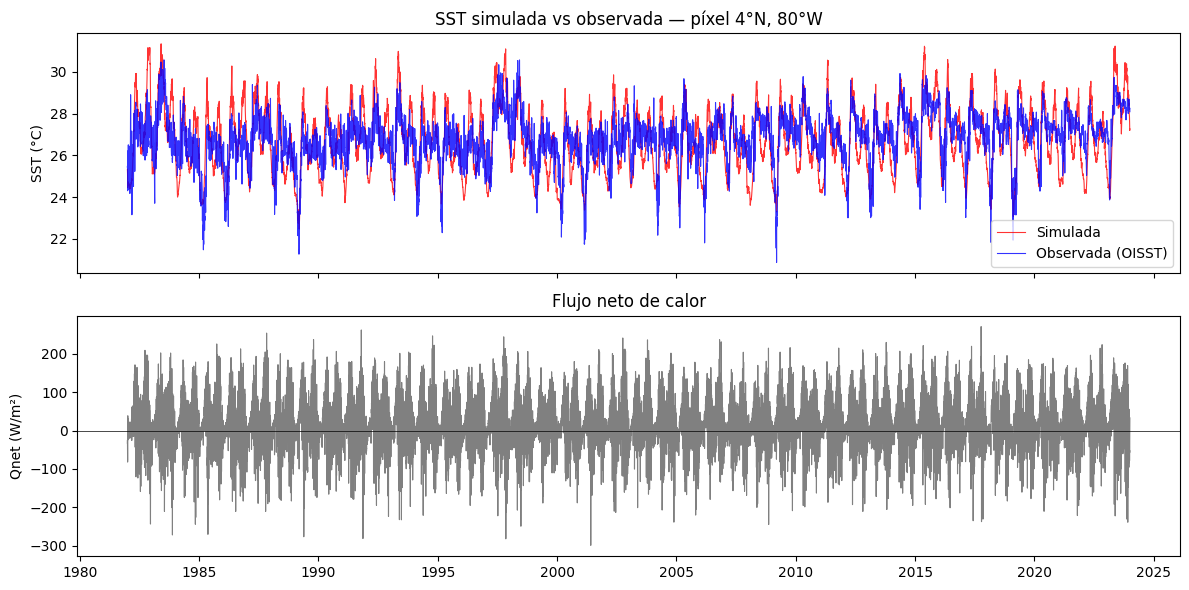

RMSE: 1.22 °C
Bias: -0.11 °C
Correlación: 0.659


In [72]:

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

tiempo_plot = oisst.time.values

axes[0].plot(tiempo_plot, sst_sim, label="Simulada", color="red", lw=0.8, alpha=0.8)
axes[0].plot(tiempo_plot, sst_obs, label="Observada (OISST)", color="blue", lw=0.8, alpha=0.8)
axes[0].set_ylabel("SST (°C)")
axes[0].legend()
axes[0].set_title("SST simulada vs observada — píxel 4°N, 80°W")

axes[1].plot(tiempo_plot, qnet, color="gray", lw=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Qnet (W/m²)")
axes[1].set_title("Flujo neto de calor")

plt.tight_layout()
plt.savefig("../docs/sst_simulada_vs_observada.png", dpi=150, bbox_inches="tight")
plt.show()

rmse = np.sqrt(np.mean((sst_sim - sst_obs)**2))
bias = np.mean(sst_sim - sst_obs)
corr = np.corrcoef(sst_obs, sst_sim)[0, 1]
print(f"RMSE: {rmse:.2f} °C")
print(f"Bias: {bias:.2f} °C")
print(f"Correlación: {corr:.3f}")

In [73]:
# Mascara de pixeles oceanicos (no NaN en OISST)
mascara_oceano = ~np.isnan(oisst["sst"].isel(time=0).values)
print(f"Píxeles totales: {mascara_oceano.size}")
print(f"Píxeles oceánicos: {mascara_oceano.sum()}")

# Coordenadas
lats = era5.latitude.values
lons = era5.longitude.values

# Periodo OISST
idx_ini = np.where(era5.time.values == np.datetime64("1982-01-01"))[0][0]
tiempo  = oisst.time.values
n_dias  = len(tiempo)
n_lat   = len(lats)
n_lon   = len(lons)

# Arrays de salida
sst_simulada = np.full((n_dias, n_lat, n_lon), np.nan)
qnet_total   = np.full((n_dias, n_lat, n_lon), np.nan)

print(f"Shape salida: {sst_simulada.shape}")
print(f"Corriendo modelo en {mascara_oceano.sum()} píxeles...")

Píxeles totales: 957
Píxeles oceánicos: 541
Shape salida: (15340, 33, 29)
Corriendo modelo en 541 píxeles...


In [74]:
from tqdm import tqdm

# Cargar todos los forzamientos en memoria
t2m_all  = era5["t2m"].values[idx_ini:]
q_all    = era5["q"].values[idx_ini:]
wspd_all = era5["wspd"].values[idx_ini:]
sw_all   = era5["sw"].values[idx_ini:] * SW_FACTOR
lw_all   = era5["lw"].values[idx_ini:]
mld_all  = mld["mld"].values  # (12, 33, 29)

# SST inicial: primer valor OISST observado por pixel
sst_ini_all = oisst["sst"].isel(time=0).values

# Interpolar OISST al grid ERA5 para la mascara
from scipy.interpolate import RegularGridInterpolator
oisst_lats = oisst.latitude.values.astype(float)
oisst_lons = oisst.longitude.values.astype(float)

interp_ini = RegularGridInterpolator(
    (oisst_lats, oisst_lons),
    sst_ini_all,
    method="linear", bounds_error=False, fill_value=np.nan
)
pts = np.array([[la, lo] for la in lats for lo in lons])
sst_ini_era5 = interp_ini(pts).reshape(n_lat, n_lon)

print("SST inicial interpolada al grid ERA5:")
print(f"  min/max: {np.nanmin(sst_ini_era5):.2f} -- {np.nanmax(sst_ini_era5):.2f} °C")
print(f"  NaN: {np.isnan(sst_ini_era5).sum()}")

SST inicial interpolada al grid ERA5:
  min/max: 22.84 -- 28.61 °C
  NaN: 476


In [75]:
# Loop sobre todos los pixeles oceanicos
contador = 0
for i in range(n_lat):
    for j in range(n_lon):
        if np.isnan(sst_ini_era5[i, j]):
            continue

        sst_sim_px, qnet_px = correr_modelo(
            t2m_all[:, i, j],
            q_all[:, i, j],
            wspd_all[:, i, j],
            sw_all[:, i, j],
            lw_all[:, i, j],
            mld_all[:, i, j],
            sst_ini=sst_ini_era5[i, j],
            tiempo=tiempo
        )

        sst_simulada[:, i, j] = sst_sim_px
        qnet_total[:, i, j]   = qnet_px
        contador += 1

print(f"Píxeles procesados: {contador}")
print(f"SST simulada rango: {np.nanmin(sst_simulada):.2f} -- {np.nanmax(sst_simulada):.2f} °C")

Píxeles procesados: 481
SST simulada rango: 20.41 -- 38.98 °C


Guardado sst_control.nc


/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/204531075.py:31: RuntimeWarning: Mean of empty slice
  sst_sim_media = np.nanmean(sst_simulada, axis=0)


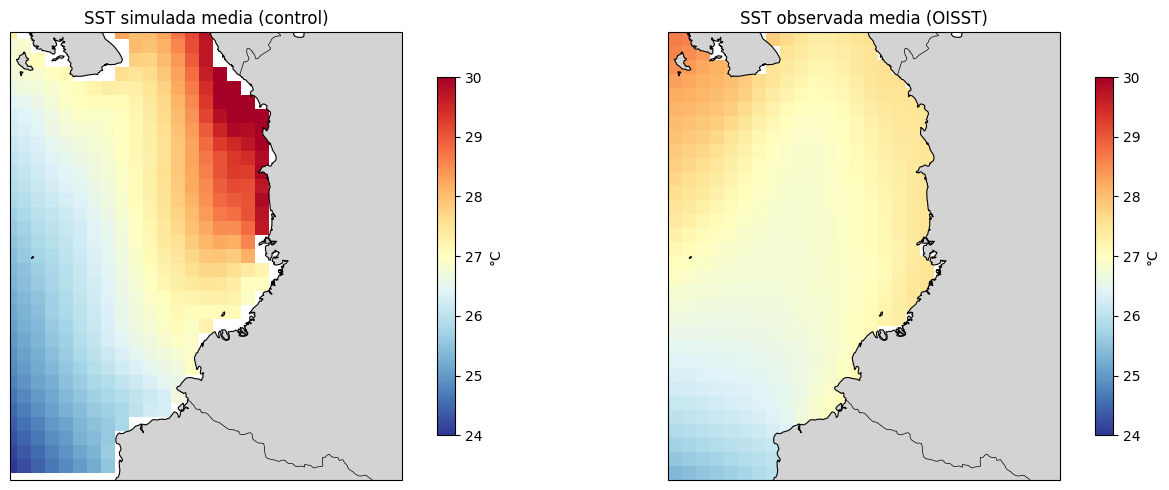

In [76]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Guardar SST simulada control
ds_control = xr.Dataset({
    "sst_sim": xr.DataArray(
        sst_simulada,
        dims=["time", "latitude", "longitude"],
        coords={
            "time": tiempo,
            "latitude": lats,
            "longitude": lons,
        },
        attrs={"units": "degC", "long_name": "SST simulada control"}
    ),
    "qnet": xr.DataArray(
        qnet_total,
        dims=["time", "latitude", "longitude"],
        coords={
            "time": tiempo,
            "latitude": lats,
            "longitude": lons,
        },
        attrs={"units": "W/m2", "long_name": "Flujo neto de calor control"}
    )
})

ds_control.to_netcdf("../datos/procesados/sst_control.nc")
print("Guardado sst_control.nc")

sst_sim_media = np.nanmean(sst_simulada, axis=0)
sst_obs_media = oisst["sst"].mean(dim="time").values

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={"projection": proj})

for ax, data, x, y, titulo in [
    (axes[0], sst_sim_media, lons, lats, "SST simulada media (control)"),
    (axes[1], sst_obs_media, oisst_lons, oisst_lats, "SST observada media (OISST)"),
]:
    im = ax.pcolormesh(x, y, data, cmap="RdYlBu_r", vmin=24, vmax=30,
                       transform=proj)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
    ax.set_extent([-82, -75, 0, 8], crs=proj)
    ax.set_title(titulo)
    plt.colorbar(im, ax=ax, label="°C", shrink=0.8)

plt.tight_layout()
plt.show()

RMSE espacial: 1.18 °C
Bias espacial: -0.11 °C


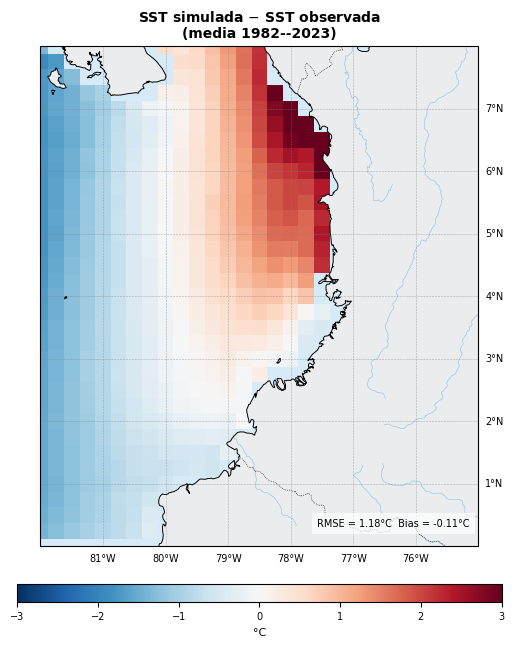

In [77]:
# Interpolar OISST observada al grid ERA5 para comparacion directa
oisst_media = oisst["sst"].mean(dim="time").values

interp_obs = RegularGridInterpolator(
    (oisst_lats, oisst_lons),
    oisst_media,
    method="linear", bounds_error=False, fill_value=np.nan
)
oisst_media_era5 = interp_obs(pts).reshape(n_lat, n_lon)

# Metricas espaciales
diff = sst_sim_media - oisst_media_era5
rmse_espacial = np.sqrt(np.nanmean(diff**2))
bias_espacial = np.nanmean(diff)
print(f"RMSE espacial: {rmse_espacial:.2f} °C")
print(f"Bias espacial: {bias_espacial:.2f} °C")

# Mapa de diferencia con estilo consistente
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(6, 7), subplot_kw={"projection": proj})

im = ax.pcolormesh(lons, lats, diff, cmap="RdBu_r", vmin=-3, vmax=3, transform=proj)

ax.add_feature(cfeature.OCEAN,     facecolor="#d6eaf8", zorder=0)
ax.add_feature(cfeature.LAND,      facecolor="#eaecee", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7,       zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=":", zorder=3)
ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor="#85c1e9", zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = True
gl.left_labels  = False
gl.xlabel_style = {"size": 7}
gl.ylabel_style = {"size": 7}

ax.set_extent([-82, -75, 0, 8], crs=proj)
ax.set_title("SST simulada $-$ SST observada\n(media 1982--2023)",
             fontsize=10, fontweight="bold", pad=6)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                    pad=0.06, shrink=0.85, aspect=28)
cbar.set_label("°C", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.text(0.98, 0.04,
        f"RMSE = {rmse_espacial:.2f}°C  Bias = {bias_espacial:+.2f}°C",
        transform=ax.transAxes, fontsize=7, ha="right",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.tight_layout()
plt.savefig("../docs/sst_simulada_vs_observada_media.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
# Sesgo estacional en el pixel de prueba (4N, 80W)
import pandas as pd

df = pd.DataFrame({
    "sst_sim": sst_sim,  # del pixel de prueba ya calculado
    "sst_obs": sst_obs
}, index=pd.DatetimeIndex(tiempo))

sesgo_mensual = (df["sst_sim"] - df["sst_obs"]).groupby(df.index.month).mean()
corr_mensual  = df.groupby(df.index.month).apply(
    lambda x: x["sst_sim"].corr(x["sst_obs"])
)

print("Sesgo mensual (simulada - observada) en 4N, 80W:")
for mes, val in sesgo_mensual.items():
    print(f"  Mes {mes:02d}: {val:+.2f} °C  corr={corr_mensual[mes]:.3f}")

Sesgo mensual (simulada - observada) en 4N, 80W:
  Mes 01: -1.39 °C  corr=0.620
  Mes 02: -1.17 °C  corr=0.698
  Mes 03: -0.24 °C  corr=0.673
  Mes 04: +0.76 °C  corr=0.631
  Mes 05: +1.08 °C  corr=0.531
  Mes 06: +0.49 °C  corr=0.714
  Mes 07: -0.70 °C  corr=0.724
  Mes 08: -1.15 °C  corr=0.693
  Mes 09: -0.60 °C  corr=0.628
  Mes 10: +0.74 °C  corr=0.494
  Mes 11: +1.04 °C  corr=0.625
  Mes 12: -0.22 °C  corr=0.504


In [79]:
# Analisis ENSO: comparar anomalias de SST simulada vs observada
# durante eventos El Nino y La Nina documentados

# Anomalias respecto a la media climatologica
sst_sim_anom = sst_sim - np.nanmean(sst_sim)
sst_obs_anom = sst_obs - np.nanmean(sst_obs)

# Eventos ENSO documentados para el Pacifico colombiano
eventos = {
    "El Nino 1982-83":  ("1982-06-01", "1983-06-30"),
    "La Nina 1988-89":  ("1988-06-01", "1989-06-30"),
    "El Nino 1997-98":  ("1997-06-01", "1998-06-30"),
    "La Nina 1999-00":  ("1999-06-01", "2000-06-30"),
    "La Nina 2010-11":  ("2010-06-01", "2011-06-30"),
    "El Nino 2015-16":  ("2015-06-01", "2016-06-30"),
}

df_anom = pd.DataFrame({
    "sim": sst_sim_anom,
    "obs": sst_obs_anom
}, index=pd.DatetimeIndex(tiempo))

print("Anomalia media de SST durante eventos ENSO (4N, 80W):")
print(f"{'Evento':<22} {'Obs (°C)':>10} {'Sim (°C)':>10} {'Signo OK':>10}")
print("-" * 55)
for nombre, (ini, fin) in eventos.items():
    obs_mean = df_anom.loc[ini:fin, "obs"].mean()
    sim_mean = df_anom.loc[ini:fin, "sim"].mean()
    signo_ok = "✓" if np.sign(obs_mean) == np.sign(sim_mean) else "✗"
    print(f"{nombre:<22} {obs_mean:>+10.2f} {sim_mean:>+10.2f} {signo_ok:>10}")

Anomalia media de SST durante eventos ENSO (4N, 80W):
Evento                   Obs (°C)   Sim (°C)   Signo OK
-------------------------------------------------------
El Nino 1982-83             +0.63      +1.35          ✓
La Nina 1988-89             -0.99      -0.97          ✓
El Nino 1997-98             +1.58      +1.60          ✓
La Nina 1999-00             -0.71      -0.97          ✓
La Nina 2010-11             +0.28      -0.39          ✗
El Nino 2015-16             +0.99      +1.21          ✓


/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/8833729.py:34: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 2
  ax.legend(handles=ax.get_legend_handles_labels()[0] + leyenda_eventos,


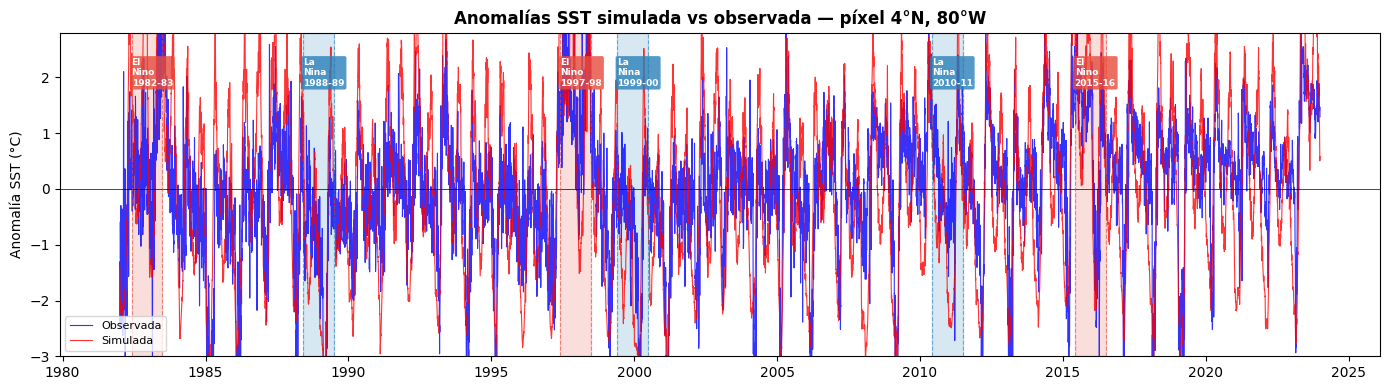

In [80]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_anom.index, df_anom["obs"], color="blue", lw=0.8, label="Observada", alpha=0.8)
ax.plot(df_anom.index, df_anom["sim"], color="red",  lw=0.8, label="Simulada",  alpha=0.8)
ax.axhline(0, color="k", lw=0.5)

# Sombrear eventos
colores = {"El Nino": "#e74c3c", "La Nina": "#2980b9"}
for nombre, (ini, fin) in eventos.items():
    color = colores["El Nino"] if "Nino" in nombre else colores["La Nina"]
    ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), alpha=0.18, color=color, zorder=0)
    # Líneas verticales en bordes
    ax.axvline(pd.Timestamp(ini), color=color, lw=0.8, ls="--", alpha=0.6)
    ax.axvline(pd.Timestamp(fin), color=color, lw=0.8, ls="--", alpha=0.6)
    # Etiqueta con fondo
    ax.text(pd.Timestamp(ini), 2.35,
            nombre.replace(" ", "\n"),
            fontsize=6.5, va="top", color="white", fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.8, edgecolor="none",
                      boxstyle="round,pad=0.2"))

ax.set_ylabel("Anomalía SST (°C)")
ax.set_title("Anomalías SST simulada vs observada — píxel 4°N, 80°W",
             fontweight="bold")
ax.legend()
ax.set_ylim(-3, 2.8)

# Leyenda de eventos
from matplotlib.patches import Patch
leyenda_eventos = [
    Patch(facecolor="#e74c3c", alpha=0.5, label="El Niño"),
    Patch(facecolor="#2980b9", alpha=0.5, label="La Niña"),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + leyenda_eventos,
          labels=ax.get_legend_handles_labels()[1],
          fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig("../docs/fig_anomalias_enso.png", dpi=150, bbox_inches="tight")
plt.show()

In [81]:
# Experimentos de perturbacion
# Mismo modelo, mismo forzamiento, solo T2m aumentada

perturbaciones = {
    "p15": 1.5,  # SSP1-2.6
    "p20": 2.0,  # SSP2-4.5
    "p40": 4.0,  # SSP5-8.5
}

resultados = {}

for nombre, delta_t in perturbaciones.items():
    print(f"Corriendo experimento +{delta_t}°C...")
    sst_exp = np.full((n_dias, n_lat, n_lon), np.nan)

    for i in range(n_lat):
        for j in range(n_lon):
            if np.isnan(sst_ini_era5[i, j]):
                continue
            sst_px, _ = correr_modelo(
                t2m_all[:, i, j] + delta_t,
                q_all[:, i, j],
                wspd_all[:, i, j],
                sw_all[:, i, j],
                lw_all[:, i, j],
                mld_all[:, i, j],
                sst_ini=sst_ini_era5[i, j],
                tiempo=tiempo
            )
            sst_exp[:, i, j] = sst_px

    resultados[nombre] = sst_exp
    print(f"  ΔSST medio: {np.nanmean(sst_exp - sst_simulada):+.3f} °C")

print("Experimentos completos.")

Corriendo experimento +1.5°C...
  ΔSST medio: +0.315 °C
Corriendo experimento +2.0°C...
  ΔSST medio: +0.420 °C
Corriendo experimento +4.0°C...
  ΔSST medio: +0.833 °C
Experimentos completos.


<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:27: SyntaxWarning: invalid escape sequence '\c'
  titulos = ["(a) SSP1-2.6 ($+1.5^{\circ}$C)",
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:28: SyntaxWarning: invalid escape sequence '\c'
  "(b) SSP2-4.5 ($+2.0^{\circ}$C)",
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:29: SyntaxWarning: invalid escape sequence '\c'
  "(c) SSP5-8.5 ($+4.0^{\circ}$C)"]


Guardado ../datos/procesados/sst_p15.nc
Guardado ../datos/procesados/sst_p20.nc
Guardado ../datos/procesados/sst_p40.nc


/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:33: RuntimeWarning: Mean of empty slice
  delta_sst = np.nanmean(resultados[nombre] - sst_simulada, axis=0)
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:33: RuntimeWarning: Mean of empty slice
  delta_sst = np.nanmean(resultados[nombre] - sst_simulada, axis=0)
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/1420672878.py:33: RuntimeWarning: Mean of empty slice
  delta_sst = np.nanmean(resultados[nombre] - sst_simulada, axis=0)


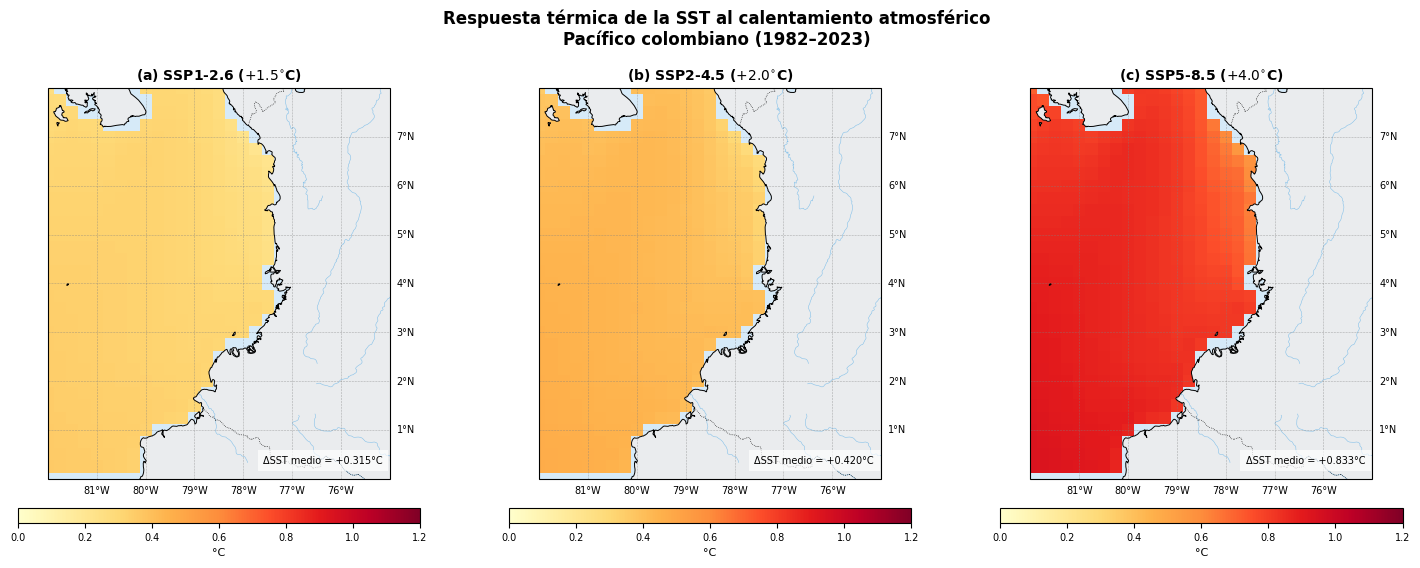

In [100]:
# Guardar experimentos
for nombre, sst_exp in resultados.items():
    delta_t = perturbaciones[nombre]
    ds_exp = xr.Dataset({
        "sst_sim": xr.DataArray(
            sst_exp,
            dims=["time", "latitude", "longitude"],
            coords={"time": tiempo, "latitude": lats, "longitude": lons},
            attrs={"units": "degC"}
        ),
        "delta_sst": xr.DataArray(
            sst_exp - sst_simulada,
            dims=["time", "latitude", "longitude"],
            coords={"time": tiempo, "latitude": lats, "longitude": lons},
            attrs={"units": "degC", "long_name": f"ΔSST para +{delta_t}°C"}
        )
    })
    path = f"../datos/procesados/sst_{nombre}.nc"
    ds_exp.to_netcdf(path)
    print(f"Guardado {path}")

# Mapas de ΔSST medio por escenario
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(15, 6),
                         subplot_kw={"projection": proj})

titulos = ["(a) SSP1-2.6 ($+1.5^{\circ}$C)",
           "(b) SSP2-4.5 ($+2.0^{\circ}$C)",
           "(c) SSP5-8.5 ($+4.0^{\circ}$C)"]
nombres = ["p15", "p20", "p40"]

for ax, nombre, titulo in zip(axes, nombres, titulos):
    delta_sst = np.nanmean(resultados[nombre] - sst_simulada, axis=0)

    im = ax.pcolormesh(lons, lats, delta_sst, cmap="YlOrRd",
                       vmin=0, vmax=1.2, transform=proj)

    ax.add_feature(cfeature.OCEAN,     facecolor="#d6eaf8", zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor="#eaecee", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7,       zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=":", zorder=3)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor="#85c1e9", zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                      alpha=0.6, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = True
    gl.left_labels  = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

    ax.set_extent([-82, -75, 0, 8], crs=proj)
    ax.set_title(titulo, fontsize=10, fontweight="bold", pad=6)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.06, shrink=0.85, aspect=28)
    cbar.set_label("°C", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.text(0.98, 0.04,
            f"ΔSST medio = {np.nanmean(delta_sst):+.3f}°C",
            transform=ax.transAxes, fontsize=7, ha="right",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.suptitle("Respuesta térmica de la SST al calentamiento atmosférico\nPacífico colombiano (1982–2023)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/fig_delta_sst_escenarios.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
# Cargar CHIRPS
chirps = xr.open_dataset("../datos/procesados/chirps_procesado.nc")

# Calcular SST mensual media sobre el dominio oceanico
# como indice regional de SST
sst_mensual = xr.DataArray(
    sst_simulada,
    dims=["time", "latitude", "longitude"],
    coords={"time": tiempo, "latitude": lats, "longitude": lons}
).resample(time="1MS").mean()

sst_mensual_regional = sst_mensual.mean(dim=["latitude", "longitude"])

# Precipitacion mensual media sobre region costera/andina
precip_mensual = chirps["precip"].mean(dim=["latitude", "longitude"])

# Alinear periodos
t_ini = max(sst_mensual_regional.time.values[0], precip_mensual.time.values[0])
t_fin = min(sst_mensual_regional.time.values[-1], precip_mensual.time.values[-1])

sst_cal   = sst_mensual_regional.sel(time=slice(t_ini, "2023-12-01")).values
precip_cal = precip_mensual.sel(time=slice(t_ini, "2023-12-01")).values

print(f"Periodo calibracion: {t_ini} -- 2023-12-01")
print(f"N meses: {len(sst_cal)}")
print(f"SST media: {sst_cal.mean():.2f} °C")
print(f"Precip media: {precip_cal.mean():.1f} mm/mes")

Periodo calibracion: 1982-01-01T00:00:00.000000000 -- 2023-12-01
N meses: 504
SST media: 26.87 °C
Precip media: 253.2 mm/mes


Relacion empirica P = 31.7 * SST + -599.9
R²: 0.364
p-valor: 0.0000
Pendiente: 31.7 mm/mes por °C


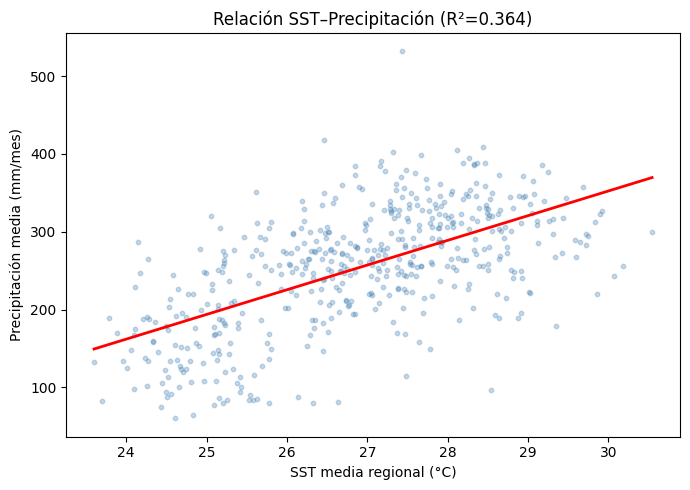

In [84]:
from scipy import stats

# Regresion lineal SST -> Precipitacion
slope, intercept, r, p, se = stats.linregress(sst_cal, precip_cal)

print(f"Relacion empirica P = {slope:.1f} * SST + {intercept:.1f}")
print(f"R²: {r**2:.3f}")
print(f"p-valor: {p:.4f}")
print(f"Pendiente: {slope:.1f} mm/mes por °C")

# Visualizar
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sst_cal, precip_cal, alpha=0.3, s=10, color="steelblue")
sst_range = np.linspace(sst_cal.min(), sst_cal.max(), 100)
ax.plot(sst_range, slope * sst_range + intercept, color="red", lw=2)
ax.set_xlabel("SST media regional (°C)")
ax.set_ylabel("Precipitación media (mm/mes)")
ax.set_title(f"Relación SST–Precipitación (R²={r**2:.3f})")
plt.tight_layout()
plt.show()

In [85]:
# Delta SST regional medio por escenario
print("=== Cambio estimado en precipitacion por escenario ===\n")

for nombre, delta_t in perturbaciones.items():
    delta_sst_regional = np.nanmean(resultados[nombre] - sst_simulada)
    delta_precip = slope * delta_sst_regional
    precip_futura = precip_cal.mean() + delta_precip
    cambio_pct = (delta_precip / precip_cal.mean()) * 100

    print(f"Escenario +{delta_t}°C (SSP correspondiente):")
    print(f"  ΔSST regional:      {delta_sst_regional:+.3f} °C")
    print(f"  ΔP estimado:        {delta_precip:+.1f} mm/mes")
    print(f"  P futura estimada:  {precip_futura:.1f} mm/mes")
    print(f"  Cambio relativo:    {cambio_pct:+.1f}%")
    print()

=== Cambio estimado en precipitacion por escenario ===

Escenario +1.5°C (SSP correspondiente):
  ΔSST regional:      +0.315 °C
  ΔP estimado:        +10.0 mm/mes
  P futura estimada:  263.2 mm/mes
  Cambio relativo:    +4.0%

Escenario +2.0°C (SSP correspondiente):
  ΔSST regional:      +0.420 °C
  ΔP estimado:        +13.3 mm/mes
  P futura estimada:  266.5 mm/mes
  Cambio relativo:    +5.3%

Escenario +4.0°C (SSP correspondiente):
  ΔSST regional:      +0.833 °C
  ΔP estimado:        +26.5 mm/mes
  P futura estimada:  279.6 mm/mes
  Cambio relativo:    +10.4%



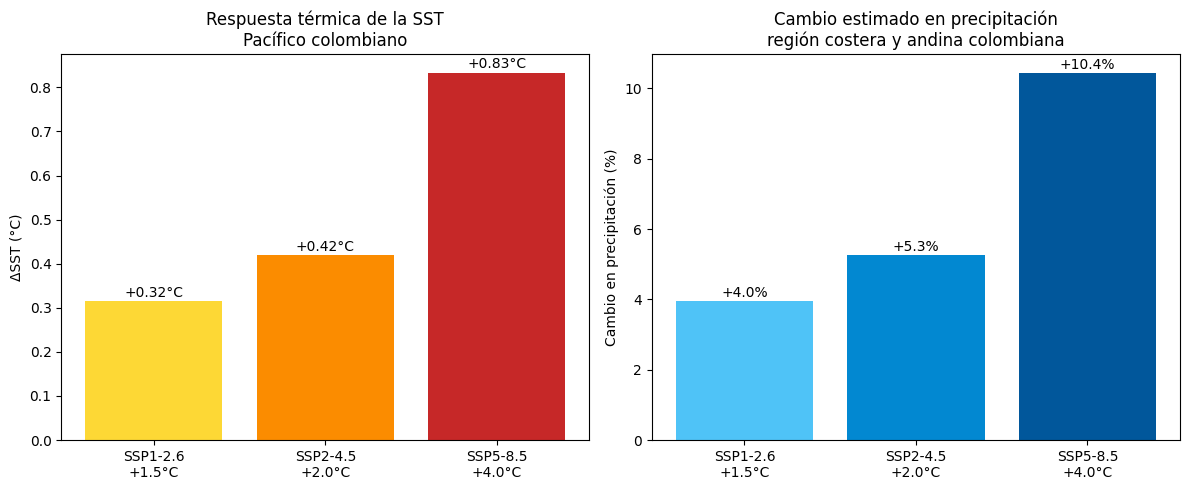

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: ΔSST por escenario
delta_t_vals = [1.5, 2.0, 4.0]
delta_sst_vals = [np.nanmean(resultados[n] - sst_simulada) for n in ["p15", "p20", "p40"]]
delta_p_vals = [slope * d for d in delta_sst_vals]
cambio_pct_vals = [d / precip_cal.mean() * 100 for d in delta_p_vals]

axes[0].bar(["SSP1-2.6\n+1.5°C", "SSP2-4.5\n+2.0°C", "SSP5-8.5\n+4.0°C"],
            delta_sst_vals, color=["#FDD835", "#FB8C00", "#C62828"])
axes[0].set_ylabel("ΔSST (°C)")
axes[0].set_title("Respuesta térmica de la SST\nPacífico colombiano")
for i, v in enumerate(delta_sst_vals):
    axes[0].text(i, v + 0.01, f"+{v:.2f}°C", ha="center", fontsize=10)

# Panel derecho: ΔP por escenario
axes[1].bar(["SSP1-2.6\n+1.5°C", "SSP2-4.5\n+2.0°C", "SSP5-8.5\n+4.0°C"],
            cambio_pct_vals, color=["#4FC3F7", "#0288D1", "#01579B"])
axes[1].set_ylabel("Cambio en precipitación (%)")
axes[1].set_title("Cambio estimado en precipitación\nregión costera y andina colombiana")
for i, v in enumerate(cambio_pct_vals):
    axes[1].text(i, v + 0.1, f"+{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../docs/fig_resultados_finales.png", dpi=150)
plt.show()

In [87]:
# Descomponer Qnet en componentes para control y cada escenario
# Usando el pixel de prueba (4N, 80W) como representativo

def balance_componentes(t2m, q, wspd, sw, lw, sst_serie):
    n = len(t2m)
    Qsw_arr = np.full(n, np.nan)
    Qlw_arr = np.full(n, np.nan)
    Ql_arr  = np.full(n, np.nan)
    Qs_arr  = np.full(n, np.nan)

    for i in range(n):
        Ql, Qs, _ = flujos_coare(sst_serie[i], t2m[i], q[i], wspd[i])
        _, Qsw, Qlw = flujo_neto(sst_serie[i], sw[i], lw[i], Ql, Qs)
        Qsw_arr[i] = Qsw
        Qlw_arr[i] = Qlw
        Ql_arr[i]  = Ql
        Qs_arr[i]  = Qs

    return Qsw_arr, Qlw_arr, Ql_arr, Qs_arr

# Control
Qsw_c, Qlw_c, Ql_c, Qs_c = balance_componentes(
    t2m_px, q_px, wspd_px, sw_px * SW_FACTOR, lw_px, sst_sim)

# Experimento +4C (el mas extremo)
i0 = np.where(era5.latitude.values == era5.sel(latitude=4.0, method="nearest").latitude.values)[0][0]
j0 = np.where(era5.longitude.values == era5.sel(longitude=-80.0, method="nearest").longitude.values)[0][0]

sst_p40_px = resultados["p40"][:, i0, j0]

Qsw_p, Qlw_p, Ql_p, Qs_p = balance_componentes(
    t2m_px + 4.0, q_px, wspd_px, sw_px * SW_FACTOR, lw_px, sst_p40_px)

# Diferencias en cada componente
print("=== Cambio en componentes del balance de calor (Control vs +4°C) ===")
print(f"ΔQsw (solar neto):     {np.nanmean(Qsw_p - Qsw_c):+.2f} W/m2")
print(f"ΔQlw (infrarrojo neto):{np.nanmean(Qlw_p - Qlw_c):+.2f} W/m2")
print(f"ΔQl  (calor latente):  {np.nanmean(Ql_p  - Ql_c):+.2f} W/m2")
print(f"ΔQs  (calor sensible): {np.nanmean(Qs_p  - Qs_c):+.2f} W/m2")
print(f"ΔQnet total:           {np.nanmean((Qsw_p+Qlw_p-Ql_p-Qs_p)-(Qsw_c+Qlw_c-Ql_c-Qs_c)):+.2f} W/m2")

=== Cambio en componentes del balance de calor (Control vs +4°C) ===
ΔQsw (solar neto):     +0.00 W/m2
ΔQlw (infrarrojo neto):-5.09 W/m2
ΔQl  (calor latente):  +19.06 W/m2
ΔQs  (calor sensible): -23.79 W/m2
ΔQnet total:           -0.36 W/m2


In [88]:
# Balance de calor: promedio espacial sobre todos los pixeles oceanicos
# Control vs +4C

Qsw_c_all = np.full((n_dias, n_lat, n_lon), np.nan)
Qlw_c_all = np.full((n_dias, n_lat, n_lon), np.nan)
Ql_c_all  = np.full((n_dias, n_lat, n_lon), np.nan)
Qs_c_all  = np.full((n_dias, n_lat, n_lon), np.nan)

Qsw_p_all = np.full((n_dias, n_lat, n_lon), np.nan)
Qlw_p_all = np.full((n_dias, n_lat, n_lon), np.nan)
Ql_p_all  = np.full((n_dias, n_lat, n_lon), np.nan)
Qs_p_all  = np.full((n_dias, n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        if np.isnan(sst_ini_era5[i, j]):
            continue
        Qsw_c_all[:, i, j], Qlw_c_all[:, i, j], Ql_c_all[:, i, j], Qs_c_all[:, i, j] = \
            balance_componentes(t2m_all[:, i, j], q_all[:, i, j], wspd_all[:, i, j],
                                sw_all[:, i, j], lw_all[:, i, j], sst_simulada[:, i, j])

        Qsw_p_all[:, i, j], Qlw_p_all[:, i, j], Ql_p_all[:, i, j], Qs_p_all[:, i, j] = \
            balance_componentes(t2m_all[:, i, j] + 4.0, q_all[:, i, j], wspd_all[:, i, j],
                                sw_all[:, i, j], lw_all[:, i, j], resultados["p40"][:, i, j])

print("=== Balance de calor espacial (promedio dominio oceanico) ===")
print(f"ΔQsw: {np.nanmean(Qsw_p_all - Qsw_c_all):+.2f} W/m2")
print(f"ΔQlw: {np.nanmean(Qlw_p_all - Qlw_c_all):+.2f} W/m2")
print(f"ΔQl:  {np.nanmean(Ql_p_all  - Ql_c_all):+.2f} W/m2")
print(f"ΔQs:  {np.nanmean(Qs_p_all  - Qs_c_all):+.2f} W/m2")

=== Balance de calor espacial (promedio dominio oceanico) ===
ΔQsw: +0.00 W/m2
ΔQlw: -4.96 W/m2
ΔQl:  +17.24 W/m2
ΔQs:  -21.86 W/m2


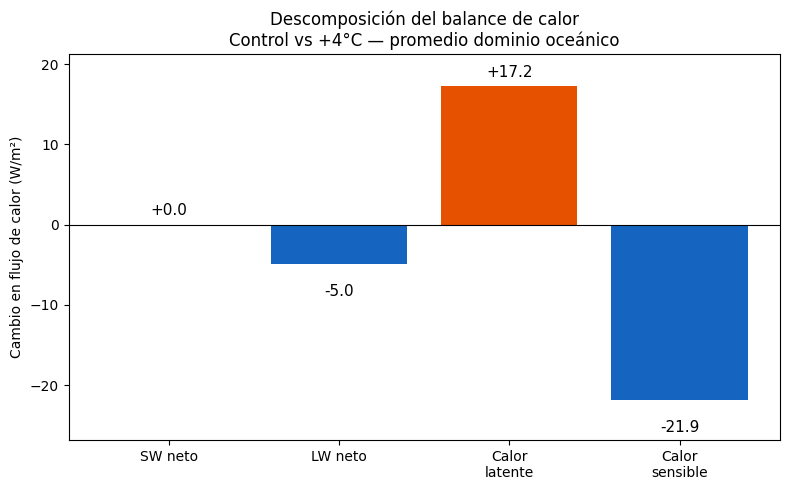

In [102]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = ["SW neto", "LW neto", "Calor\nlatente", "Calor\nsensible"]
deltas = [
    np.nanmean(Qsw_p_all - Qsw_c_all),
    np.nanmean(Qlw_p_all - Qlw_c_all),
    np.nanmean(Ql_p_all  - Ql_c_all),
    np.nanmean(Qs_p_all  - Qs_c_all),
]
colores = ["#E65100" if d >= 0 else "#1565C0" for d in deltas]

bars = ax.bar(componentes, deltas, color=colores)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Cambio en flujo de calor (W/m²)")
ax.set_title("Descomposición del balance de calor\nControl vs +4°C — promedio dominio oceánico")

for bar, val in zip(bars, deltas):
    offset = 0.8 if val >= 0 else -2.5
    va     = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset,
            f"{val:+.1f}", ha="center", va=va, fontsize=11)

ax.set_ylim(min(deltas) - 5, max(deltas) + 4)

plt.tight_layout()
plt.savefig("../docs/fig_balance_calor.png", dpi=150)
plt.show()

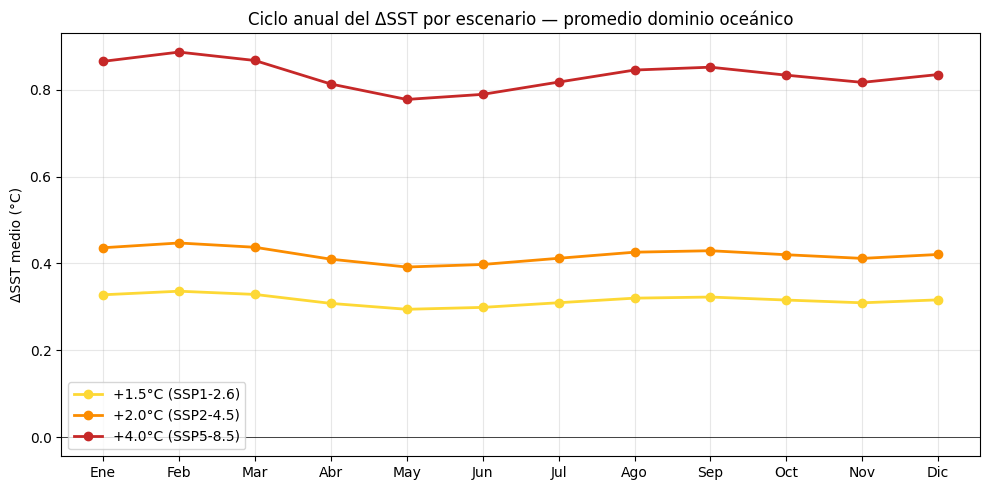

In [90]:
# Ciclo estacional del ΔSST: promedio espacial por mes
fig, ax = plt.subplots(figsize=(10, 5))

meses_label = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]
colores_exp = {"p15": "#FDD835", "p20": "#FB8C00", "p40": "#C62828"}
labels_exp  = {"p15": "+1.5°C (SSP1-2.6)", "p20": "+2.0°C (SSP2-4.5)", "p40": "+4.0°C (SSP5-8.5)"}

tiempo_dt = pd.DatetimeIndex(tiempo)

for nombre in ["p15", "p20", "p40"]:
    delta_sst_espacial = np.nanmean(resultados[nombre] - sst_simulada, axis=(1, 2))
    df_delta = pd.Series(delta_sst_espacial, index=tiempo_dt)
    ciclo = df_delta.groupby(df_delta.index.month).mean()
    ax.plot(range(1, 13), ciclo.values,
            marker="o", color=colores_exp[nombre],
            label=labels_exp[nombre], lw=2)

ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_label)
ax.set_ylabel("ΔSST medio (°C)")
ax.set_title("Ciclo anual del ΔSST por escenario — promedio dominio oceánico")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/fig_ciclo_anual_delta_sst.png", dpi=150)
plt.show()

In [91]:
# Recalcular oisst_era5
oisst_era5 = np.full((len(tiempo), n_lat, n_lon), np.nan)

for t in range(len(tiempo)):
    interp_t = RegularGridInterpolator(
        (oisst_lats, oisst_lons),
        oisst["sst"].values[t],
        method="linear", bounds_error=False, fill_value=np.nan
    )
    oisst_era5[t] = interp_t(pts).reshape(n_lat, n_lon)

print(f"oisst_era5 shape: {oisst_era5.shape}")
print(f"NaN primer timestep: {np.isnan(oisst_era5[0]).sum()}")

oisst_era5 shape: (15340, 33, 29)
NaN primer timestep: 476


In [92]:
from scipy.interpolate import RegularGridInterpolator

oisst_vals = oisst["sst"].values.astype(float)  # (15340, 33, 29)
oisst_lats_f = oisst_lats.astype(float)
oisst_lons_f = oisst_lons.astype(float)
pts = np.array([[la, lo] for la in lats for lo in lons])

oisst_era5 = np.full((len(tiempo), n_lat, n_lon), np.nan)

# Una sola instancia del interpolador, aplicada a todos los tiempos
for t in range(len(tiempo)):
    interp_t = RegularGridInterpolator(
        (oisst_lats_f, oisst_lons_f),
        oisst_vals[t],
        method="nearest",   # nearest es mucho mas rapido que linear
        bounds_error=False, fill_value=np.nan
    )
    oisst_era5[t] = interp_t(pts).reshape(n_lat, n_lon)

print("Listo:", oisst_era5.shape)

Listo: (15340, 33, 29)


In [93]:
from scipy.stats import linregress

tendencia_sim = np.full((n_lat, n_lon), np.nan)
tendencia_obs = np.full((n_lat, n_lon), np.nan)

x = np.arange(n_dias, dtype=float)

for i in range(n_lat):
    for j in range(n_lon):
        if np.isnan(sst_ini_era5[i, j]):
            continue

        serie_sim = sst_simulada[:, i, j]
        if not np.all(np.isnan(serie_sim)):
            sl, _, _, _, _ = linregress(x, serie_sim)
            tendencia_sim[i, j] = sl * 3650

        serie_obs = oisst_era5[:, i, j]
        if not np.all(np.isnan(serie_obs)):
            sl, _, _, _, _ = linregress(x, serie_obs)
            tendencia_obs[i, j] = sl * 3650

print(f"Tendencia sim media:  {np.nanmean(tendencia_sim):+.3f} °C/decada")
print(f"Tendencia obs media:  {np.nanmean(tendencia_obs):+.3f} °C/decada")

Tendencia sim media:  +0.056 °C/decada
Tendencia obs media:  +0.200 °C/decada


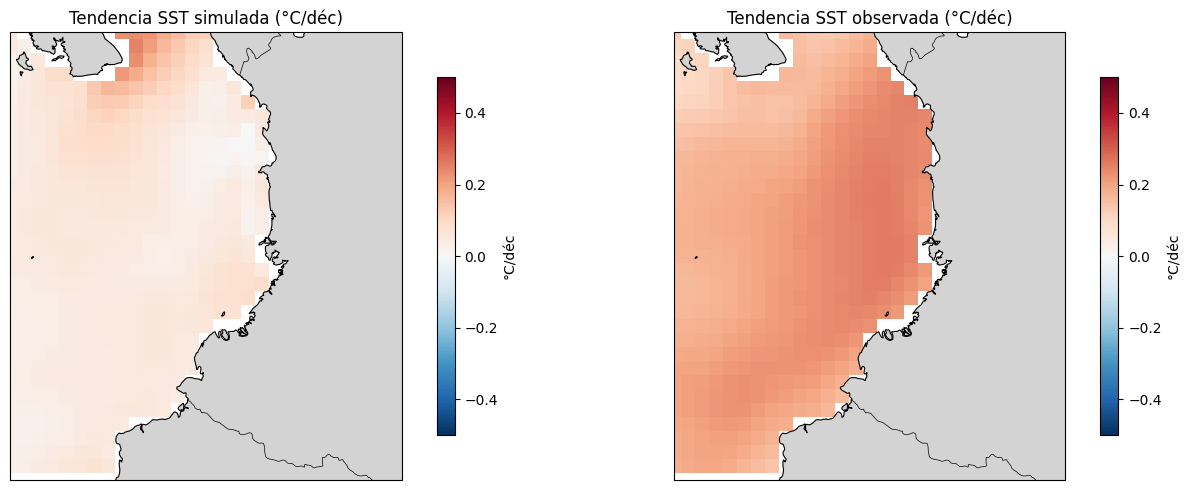

In [94]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={"projection": proj})

for ax, data, titulo in [
    (axes[0], tendencia_sim, "Tendencia SST simulada (°C/déc)"),
    (axes[1], tendencia_obs, "Tendencia SST observada (°C/déc)"),
]:
    im = ax.pcolormesh(lons, lats, data, cmap="RdBu_r",
                       vmin=-0.5, vmax=0.5, transform=proj)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
    ax.set_extent([-82, -75, 0, 8], crs=proj)
    ax.set_title(titulo)
    plt.colorbar(im, ax=ax, label="°C/déc", shrink=0.8)

plt.tight_layout()
plt.savefig("../docs/fig_tendencia_sst_mapa.png", dpi=150)
plt.show()

In [95]:
from scipy.stats import linregress

np.random.seed(42)
n_bootstrap = 1000
slopes_boot = np.full(n_bootstrap, np.nan)

for b in range(n_bootstrap):
    idx = np.random.choice(len(sst_cal), len(sst_cal), replace=True)
    s, _, _, _, _ = linregress(sst_cal[idx], precip_cal[idx])
    slopes_boot[b] = s

slope_p5  = np.percentile(slopes_boot, 2.5)
slope_p95 = np.percentile(slopes_boot, 97.5)

print(f"Pendiente SST-P:  {slope:.1f} mm/mes/°C")
print(f"IC 95%:           [{slope_p5:.1f}, {slope_p95:.1f}] mm/mes/°C")
print()
print(f"{'Escenario':<20} {'ΔSST':>8} {'ΔP central':>12} {'IC 95%':>20} {'Cambio %':>10}")
print("-" * 75)
for nombre, delta_t in perturbaciones.items():
    delta_sst = np.nanmean(resultados[nombre] - sst_simulada)
    dp_c  = slope    * delta_sst
    dp_l  = slope_p5  * delta_sst
    dp_h  = slope_p95 * delta_sst
    pct_c = dp_c / precip_cal.mean() * 100
    pct_l = dp_l / precip_cal.mean() * 100
    pct_h = dp_h / precip_cal.mean() * 100
    label = f"+{delta_t}°C (SSP{'1-2.6' if delta_t==1.5 else '2-4.5' if delta_t==2.0 else '5-8.5'})"
    print(f"{label:<20} {delta_sst:>+8.3f} {dp_c:>+12.1f}   [{dp_l:+.1f}, {dp_h:+.1f}]   {pct_c:>+8.1f}%")

Pendiente SST-P:  31.7 mm/mes/°C
IC 95%:           [28.3, 35.5] mm/mes/°C

Escenario                ΔSST   ΔP central               IC 95%   Cambio %
---------------------------------------------------------------------------
+1.5°C (SSP1-2.6)      +0.315        +10.0   [+8.9, +11.2]       +4.0%
+2.0°C (SSP2-4.5)      +0.420        +13.3   [+11.9, +14.9]       +5.3%
+4.0°C (SSP5-8.5)      +0.833        +26.5   [+23.5, +29.6]      +10.4%


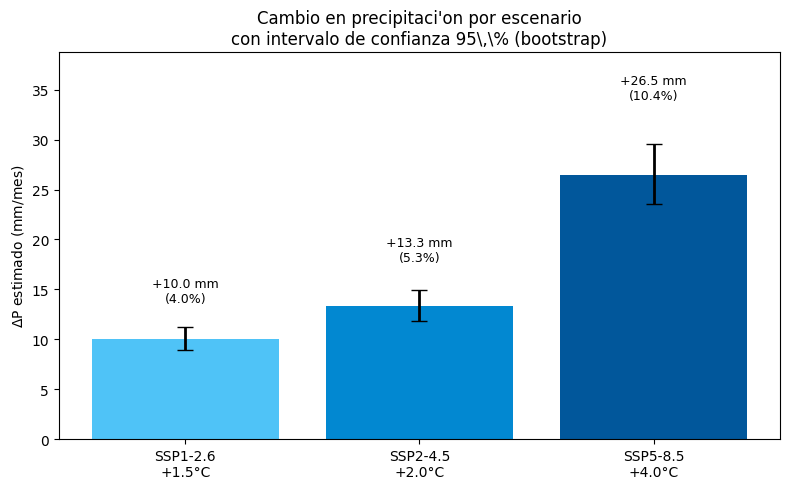

In [104]:
fig, ax = plt.subplots(figsize=(8, 5))

escenarios = ["SSP1-2.6\n+1.5°C", "SSP2-4.5\n+2.0°C", "SSP5-8.5\n+4.0°C"]
centrales  = [slope * np.nanmean(resultados[n] - sst_simulada) for n in ["p15", "p20", "p40"]]
bajos      = [slope_p5  * np.nanmean(resultados[n] - sst_simulada) for n in ["p15", "p20", "p40"]]
altos      = [slope_p95 * np.nanmean(resultados[n] - sst_simulada) for n in ["p15", "p20", "p40"]]
errores    = [[c - l for c, l in zip(centrales, bajos)],
              [h - c for c, h in zip(centrales, altos)]]

colores = ["#4FC3F7", "#0288D1", "#01579B"]
bars = ax.bar(escenarios, centrales, color=colores, yerr=errores,
              capsize=6, error_kw={"elinewidth": 2, "ecolor": "black"})

ax.set_ylabel("$\\Delta$P estimado (mm/mes)")
ax.set_title("Cambio en precipitaci\'on por escenario\ncon intervalo de confianza 95\\,\\% (bootstrap)")

# Posicionar etiqueta por encima del extremo superior de la barra de error
for bar, val, alto, pct in zip(bars, centrales, altos,
        [c / precip_cal.mean() * 100 for c in centrales]):
    tope = val + (alto - val) + errores[1][list(centrales).index(val)] + 1.0
    ax.text(bar.get_x() + bar.get_width()/2, tope,
            f"+{val:.1f} mm\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)

# Ampliar ylim para que las etiquetas no queden cortadas
ax.set_ylim(0, max(altos) + max([e for e in errores[1]]) + 6)

plt.tight_layout()
plt.savefig("../docs/fig_incertidumbre_delta_p.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/582058447.py:39: RuntimeWarning: Mean of empty slice
  sim_est = np.nanmean(sst_simulada[mask_t], axis=0)
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/582058447.py:39: RuntimeWarning: Mean of empty slice
  sim_est = np.nanmean(sst_simulada[mask_t], axis=0)
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/582058447.py:39: RuntimeWarning: Mean of empty slice
  sim_est = np.nanmean(sst_simulada[mask_t], axis=0)
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_42820/582058447.py:39: RuntimeWarning: Mean of empty slice
  sim_est = np.nanmean(sst_simulada[mask_t], axis=0)


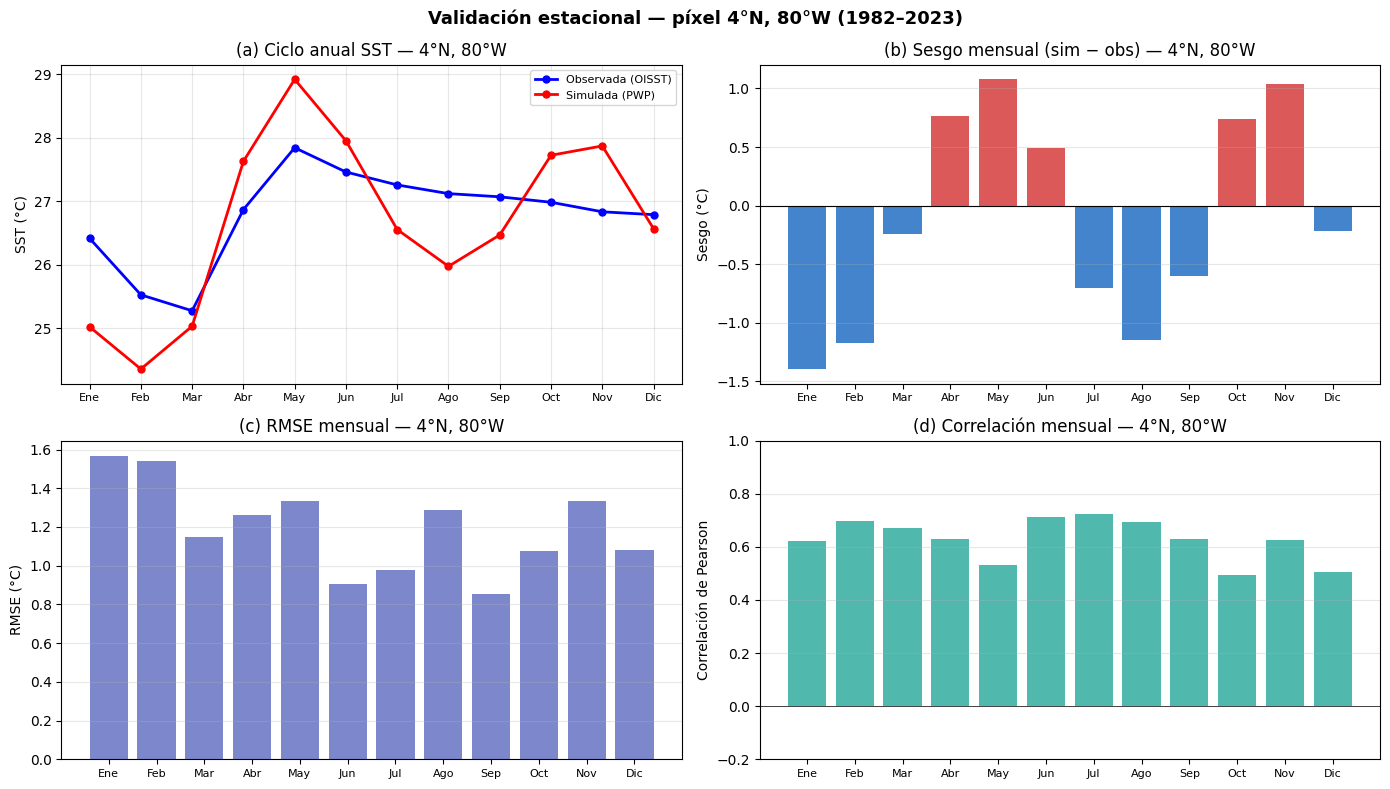

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RegularGridInterpolator

# ── Figura: validación estacional ──────────────────────────────────────────
# Usa sst_sim, sst_obs, tiempo (pixel 4N,80W) y sst_simulada, oisst (espacial)

tiempo_dt = pd.DatetimeIndex(tiempo)

# 1) Serie temporal del sesgo en el pixel de prueba
sesgo_diario = pd.Series(sst_sim - sst_obs, index=tiempo_dt)

# 2) Sesgo y RMSE mensual (pixel)
sesgo_mensual = sesgo_diario.groupby(sesgo_diario.index.month).mean()
rmse_mensual  = sesgo_diario.groupby(sesgo_diario.index.month).apply(
    lambda x: np.sqrt((x**2).mean())
)

# 3) Correlación mensual (pixel)
df_px = pd.DataFrame({"sim": sst_sim, "obs": sst_obs}, index=tiempo_dt)
corr_mensual = df_px.groupby(df_px.index.month).apply(
    lambda x: x["sim"].corr(x["obs"])
)

# 4) Ciclo anual observado vs simulado (pixel)
ciclo_obs = df_px["obs"].groupby(df_px.index.month).mean()
ciclo_sim = df_px["sim"].groupby(df_px.index.month).mean()

# 5) Sesgo estacional espacial (promedio dominio oceánico)
# Interpolar OISST al grid ERA5 para comparación directa
oisst_lats_arr = oisst["sst"].latitude.values
oisst_lons_arr = oisst["sst"].longitude.values

sesgo_estacional_espacial = {}
for estacion, meses in {"DJF": [12,1,2], "MAM": [3,4,5],
                         "JJA": [6,7,8], "SON": [9,10,11]}.items():
    mask_t = np.isin(tiempo_dt.month, meses)
    sim_est = np.nanmean(sst_simulada[mask_t], axis=0)
    
    # OISST interpolada al grid ERA5 para esta estación
    oisst_est_raw = oisst["sst"].sel(
        time=oisst["sst"].time.dt.month.isin(meses)
    ).mean(dim="time").values
    
    interp = RegularGridInterpolator(
        (oisst_lats_arr, oisst_lons_arr), oisst_est_raw,
        method="linear", bounds_error=False, fill_value=np.nan
    )
    pts_grid = np.array([[la, lo] for la in lats for lo in lons])
    obs_est = interp(pts_grid).reshape(n_lat, n_lon)
    
    sesgo_estacional_espacial[estacion] = sim_est - obs_est

# ── Figura 4a: validación temporal pixel 4°N, 80°W ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

meses_label = ["Ene","Feb","Mar","Abr","May","Jun",
               "Jul","Ago","Sep","Oct","Nov","Dic"]

# Panel 1: ciclo anual
axes[0,0].plot(range(1,13), ciclo_obs.values, "b-o", lw=2, ms=5, label="Observada (OISST)")
axes[0,0].plot(range(1,13), ciclo_sim.values, "r-o", lw=2, ms=5, label="Simulada (PWP)")
axes[0,0].set_xticks(range(1,13)); axes[0,0].set_xticklabels(meses_label, fontsize=8)
axes[0,0].set_ylabel("SST (°C)"); axes[0,0].set_title("(a) Ciclo anual SST — 4°N, 80°W")
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)

# Panel 2: sesgo mensual
colores_bar = ["#d32f2f" if v > 0 else "#1565c0" for v in sesgo_mensual.values]
axes[0,1].bar(range(1,13), sesgo_mensual.values, color=colores_bar, alpha=0.8)
axes[0,1].axhline(0, color="k", lw=0.8)
axes[0,1].set_xticks(range(1,13)); axes[0,1].set_xticklabels(meses_label, fontsize=8)
axes[0,1].set_ylabel("Sesgo (°C)"); axes[0,1].set_title("(b) Sesgo mensual (sim − obs) — 4°N, 80°W")
axes[0,1].grid(alpha=0.3, axis="y")

# Panel 3: RMSE mensual
axes[1,0].bar(range(1,13), rmse_mensual.values, color="#5c6bc0", alpha=0.8)
axes[1,0].set_xticks(range(1,13)); axes[1,0].set_xticklabels(meses_label, fontsize=8)
axes[1,0].set_ylabel("RMSE (°C)"); axes[1,0].set_title("(c) RMSE mensual — 4°N, 80°W")
axes[1,0].grid(alpha=0.3, axis="y")

# Panel 4: correlación mensual
axes[1,1].bar(range(1,13), corr_mensual.values, color="#26a69a", alpha=0.8)
axes[1,1].axhline(0, color="k", lw=0.5)
axes[1,1].set_xticks(range(1,13)); axes[1,1].set_xticklabels(meses_label, fontsize=8)
axes[1,1].set_ylabel("Correlación de Pearson")
axes[1,1].set_title("(d) Correlación mensual — 4°N, 80°W")
axes[1,1].set_ylim(-0.2, 1.0); axes[1,1].grid(alpha=0.3, axis="y")

plt.suptitle("Validación estacional — píxel 4°N, 80°W (1982–2023)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/fig_validacion_estacional_pixel.png", dpi=150, bbox_inches="tight")
plt.show()

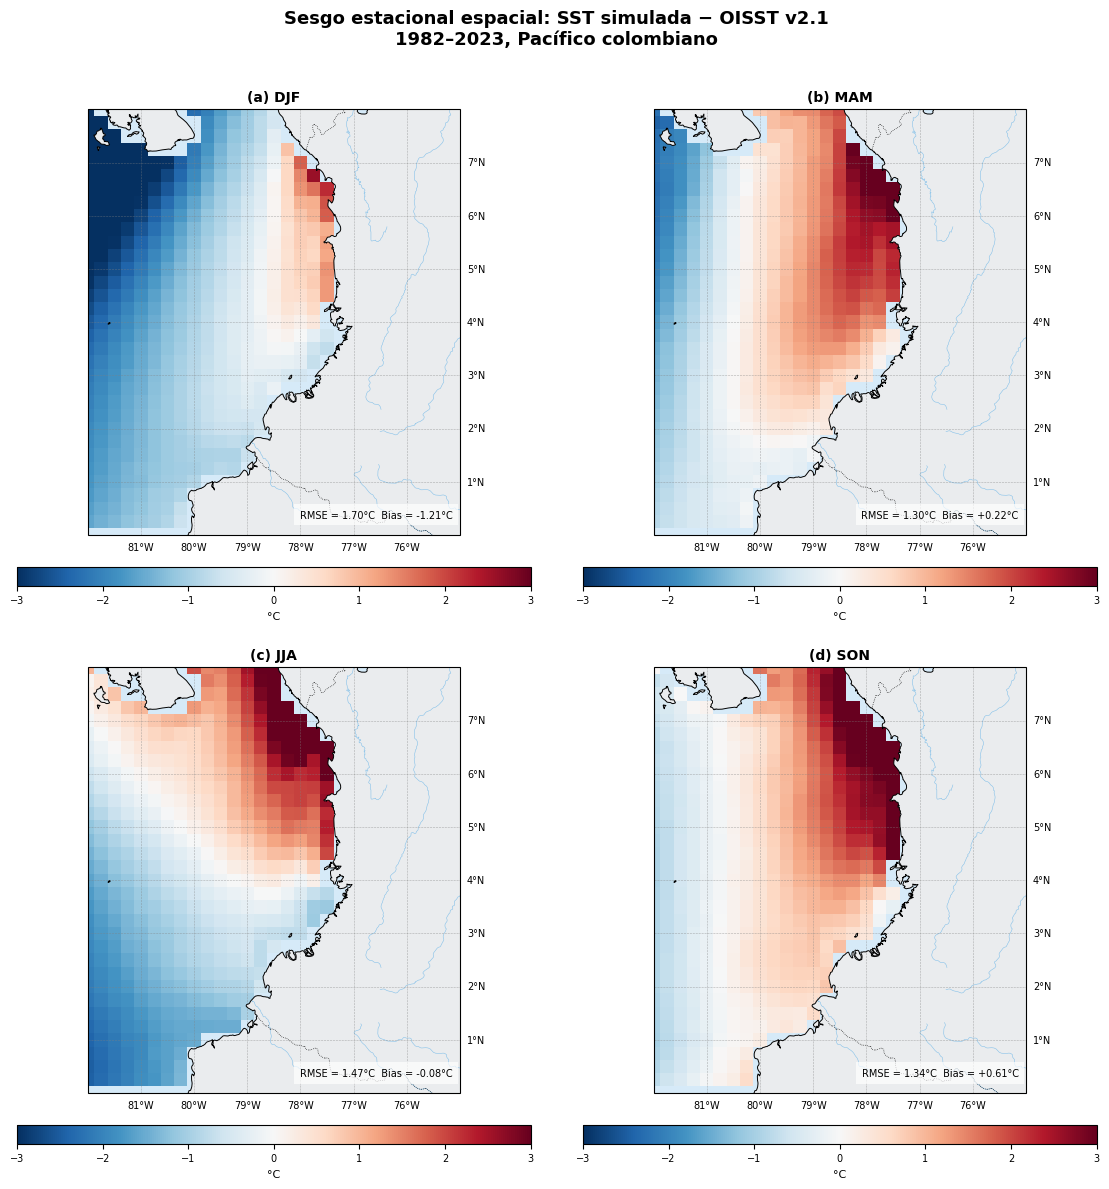

In [98]:
# ── Figura 4b: mapas de sesgo estacional espacial ──────────────────────────
proj = ccrs.PlateCarree()
estaciones  = ["DJF", "MAM", "JJA", "SON"]
titulos_est = ["(a) DJF", "(b) MAM", "(c) JJA", "(d) SON"]

fig, axes = plt.subplots(2, 2, figsize=(12, 12),
                         subplot_kw={"projection": proj})

for ax, est, titulo in zip(axes.flat, estaciones, titulos_est):
    datos    = sesgo_estacional_espacial[est]
    rmse_est = np.sqrt(np.nanmean(datos**2))
    bias_est = np.nanmean(datos)

    im = ax.pcolormesh(lons, lats, datos, cmap="RdBu_r",
                       vmin=-3, vmax=3, transform=proj)

    ax.add_feature(cfeature.OCEAN,     facecolor="#d6eaf8", zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor="#eaecee", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7,       zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=":", zorder=3)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor="#85c1e9", zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                      alpha=0.6, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = True
    gl.left_labels  = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

    ax.set_extent([-82, -75, 0, 8], crs=proj)
    ax.set_title(f"{titulo}", fontsize=10, fontweight="bold", pad=6)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.06, shrink=0.85, aspect=28)
    cbar.set_label("°C", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.text(0.98, 0.04,
            f"RMSE = {rmse_est:.2f}°C  Bias = {bias_est:+.2f}°C",
            transform=ax.transAxes, fontsize=7, ha="right",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.suptitle("Sesgo estacional espacial: SST simulada − OISST v2.1\n1982–2023, Pacífico colombiano",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../docs/fig_validacion_estacional_mapas.png", dpi=150, bbox_inches="tight")
plt.show()

=== Regresión sobre series brutas ===
  Pendiente:  31.7 mm/mes/°C
  R²:         0.364
  p-valor:    2.8005e-51
  SE:         1.9 mm/mes/°C

=== Regresión sobre anomalías (sin ciclo estacional) ===
  Pendiente:  -24.9 mm/mes/°C
  R²:         0.161
  p-valor:    7.1635e-21
  SE:         2.5 mm/mes/°C

=== Diagnóstico de residuales ===
  Media:              0.00 mm/mes  (debe ser ~0)
  Std:                61.9 mm/mes
  Shapiro-Wilk p:     0.9178  (normal)
  Durbin-Watson:      0.97  (2=sin autocorr, <2=autocorr positiva)


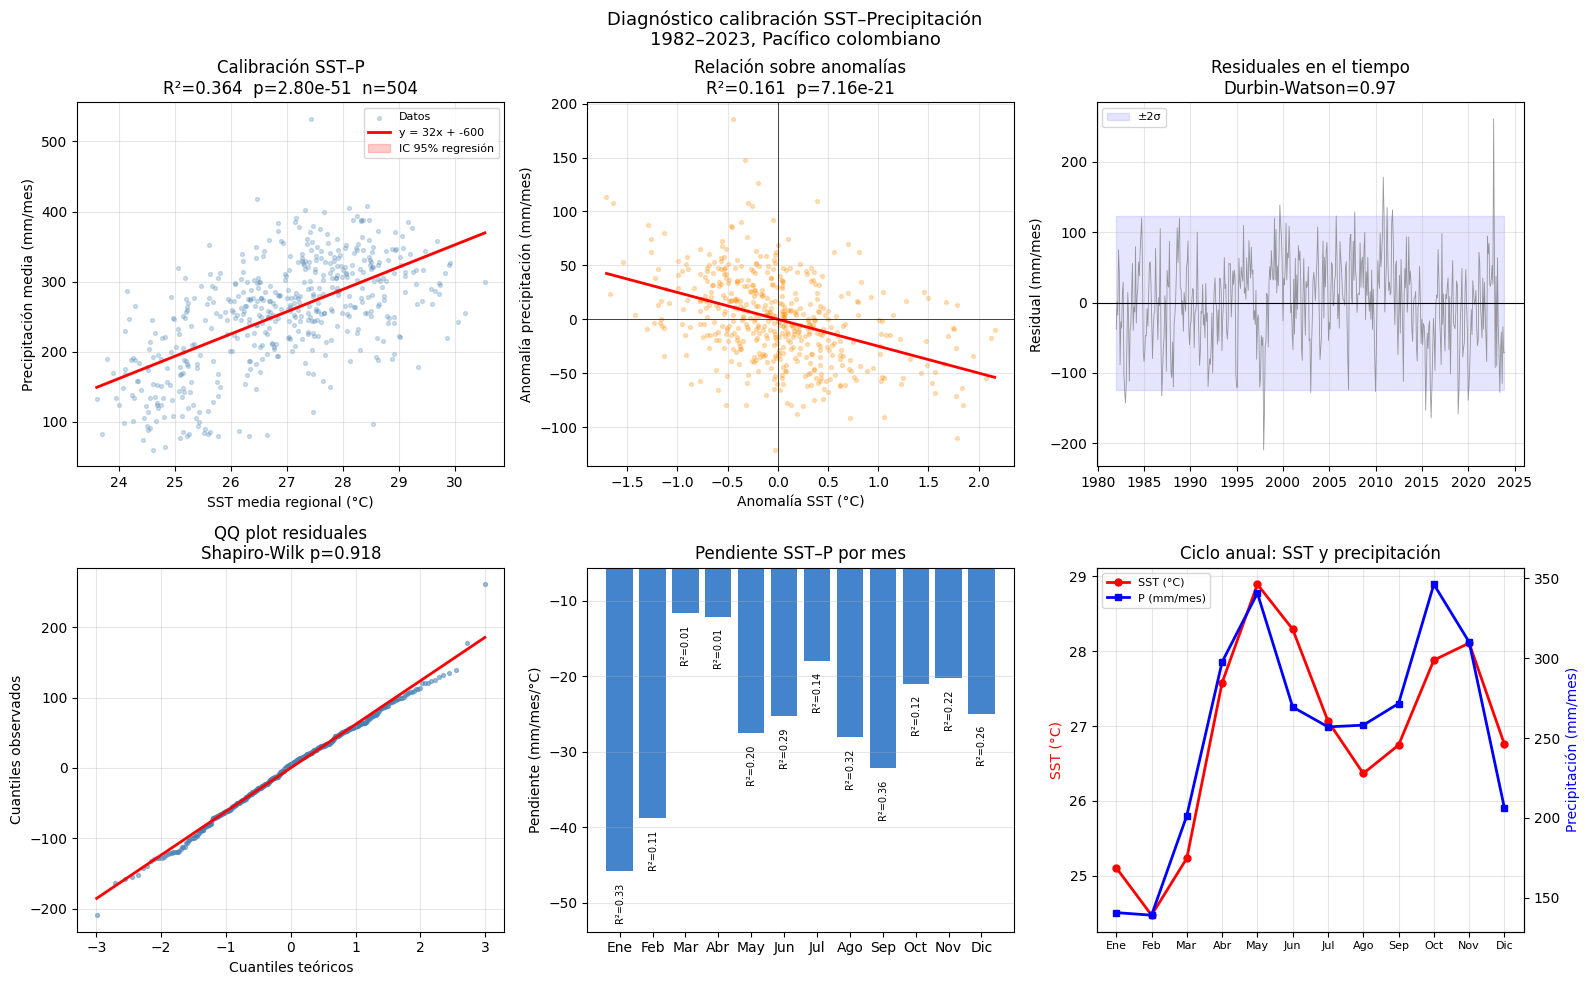

In [103]:
from scipy import stats
import pandas as pd

# ── Datos ya disponibles: sst_cal, precip_cal, slope, intercept, r, p, se ──

# 1) Anomalías (remover ciclo estacional antes de calibrar)
#    para ver si la relación es robusta más allá de la covariación estacional
t_ini_dt = pd.date_range(start="1982-01-01", periods=len(sst_cal), freq="MS")

df_cal = pd.DataFrame({
    "sst":    sst_cal,
    "precip": precip_cal
}, index=t_ini_dt)

# Ciclo estacional de cada variable
sst_clim    = df_cal["sst"].groupby(df_cal.index.month).mean()
precip_clim = df_cal["precip"].groupby(df_cal.index.month).mean()

df_cal["sst_anom"]    = df_cal["sst"]    - df_cal.index.month.map(sst_clim)
df_cal["precip_anom"] = df_cal["precip"] - df_cal.index.month.map(precip_clim)

# Regresión sobre anomalías
sl_anom, ic_anom, r_anom, p_anom, se_anom = stats.linregress(
    df_cal["sst_anom"], df_cal["precip_anom"]
)

print("=== Regresión sobre series brutas ===")
print(f"  Pendiente:  {slope:.1f} mm/mes/°C")
print(f"  R²:         {r**2:.3f}")
print(f"  p-valor:    {p:.4e}")
print(f"  SE:         {se:.1f} mm/mes/°C")
print()
print("=== Regresión sobre anomalías (sin ciclo estacional) ===")
print(f"  Pendiente:  {sl_anom:.1f} mm/mes/°C")
print(f"  R²:         {r_anom**2:.3f}")
print(f"  p-valor:    {p_anom:.4e}")
print(f"  SE:         {se_anom:.1f} mm/mes/°C")

# 2) Residuales
precip_pred = slope * sst_cal + intercept
residuales  = precip_cal - precip_pred

# Test de normalidad de residuales
stat_sw, p_sw = stats.shapiro(residuales[:50])  # Shapiro solo toma <=5000, submuestreo seguro
stat_dw = np.sum(np.diff(residuales)**2) / np.sum(residuales**2)  # Durbin-Watson

print()
print("=== Diagnóstico de residuales ===")
print(f"  Media:              {residuales.mean():.2f} mm/mes  (debe ser ~0)")
print(f"  Std:                {residuales.std():.1f} mm/mes")
print(f"  Shapiro-Wilk p:     {p_sw:.4f}  ({'normal' if p_sw > 0.05 else 'no normal'})")
print(f"  Durbin-Watson:      {stat_dw:.2f}  (2=sin autocorr, <2=autocorr positiva)")

# 3) Pendiente por mes (¿es estable todo el año?)
pendiente_mensual = {}
r2_mensual        = {}
for mes in range(1, 13):
    mask = df_cal.index.month == mes
    x_m  = df_cal.loc[mask, "sst"].values
    y_m  = df_cal.loc[mask, "precip"].values
    if len(x_m) > 5:
        sl_m, _, r_m, p_m, _ = stats.linregress(x_m, y_m)
        pendiente_mensual[mes] = sl_m
        r2_mensual[mes]        = r_m**2

# ── Figura diagnóstico ─────────────────────────────────────────────────────
meses_label = ["Ene","Feb","Mar","Abr","May","Jun",
               "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Scatter bruto + recta
ax = axes[0, 0]
ax.scatter(sst_cal, precip_cal, alpha=0.25, s=8, color="steelblue", label="Datos")
sst_rng = np.linspace(sst_cal.min(), sst_cal.max(), 100)
ax.plot(sst_rng, slope * sst_rng + intercept, "r-", lw=2,
        label=f"y = {slope:.0f}x + {intercept:.0f}")
# IC de la regresión
n_cal  = len(sst_cal)
t_crit = stats.t.ppf(0.975, df=n_cal - 2)
se_fit = se * np.sqrt(1/n_cal + (sst_rng - sst_cal.mean())**2 / np.sum((sst_cal - sst_cal.mean())**2))
ax.fill_between(sst_rng,
                slope * sst_rng + intercept - t_crit * se_fit,
                slope * sst_rng + intercept + t_crit * se_fit,
                alpha=0.2, color="red", label="IC 95% regresión")
ax.set_xlabel("SST media regional (°C)")
ax.set_ylabel("Precipitación media (mm/mes)")
ax.set_title(f"Calibración SST–P\nR²={r**2:.3f}  p={p:.2e}  n={n_cal}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Scatter anomalías
ax = axes[0, 1]
ax.scatter(df_cal["sst_anom"], df_cal["precip_anom"],
           alpha=0.25, s=8, color="darkorange")
sst_anom_rng = np.linspace(df_cal["sst_anom"].min(), df_cal["sst_anom"].max(), 100)
ax.plot(sst_anom_rng, sl_anom * sst_anom_rng + ic_anom, "r-", lw=2)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Anomalía SST (°C)")
ax.set_ylabel("Anomalía precipitación (mm/mes)")
ax.set_title(f"Relación sobre anomalías\nR²={r_anom**2:.3f}  p={p_anom:.2e}")
ax.grid(alpha=0.3)

# Panel 3: Residuales en el tiempo
ax = axes[0, 2]
ax.plot(df_cal.index, residuales, color="gray", lw=0.6, alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.fill_between(df_cal.index,
                -2 * residuales.std(), 2 * residuales.std(),
                alpha=0.1, color="blue", label="±2σ")
ax.set_ylabel("Residual (mm/mes)")
ax.set_title(f"Residuales en el tiempo\nDurbin-Watson={stat_dw:.2f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 4: QQ plot residuales
ax = axes[1, 0]
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuales, dist="norm")
ax.scatter(osm, osr, s=8, alpha=0.5, color="steelblue")
ax.plot(osm, slope_qq * np.array(osm) + intercept_qq, "r-", lw=2)
ax.set_xlabel("Cuantiles teóricos")
ax.set_ylabel("Cuantiles observados")
ax.set_title(f"QQ plot residuales\nShapiro-Wilk p={p_sw:.3f}")
ax.grid(alpha=0.3)

# Panel 5: Pendiente SST-P por mes
ax = axes[1, 1]
meses_disp = sorted(pendiente_mensual.keys())
pend_vals  = [pendiente_mensual[m] for m in meses_disp]
r2_vals    = [r2_mensual[m] for m in meses_disp]
colores_m  = ["#d32f2f" if v > 0 else "#1565c0" for v in pend_vals]
bars = ax.bar([meses_label[m-1] for m in meses_disp], pend_vals,
              color=colores_m, alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Pendiente (mm/mes/°C)")
ax.set_title("Pendiente SST–P por mes")
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(min(pend_vals) - 8, max(pend_vals) + 6)

# R² justo encima del extremo inferior de cada barra
for bar, r2, val in zip(bars, r2_vals, pend_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val - 1.5,
            f"R²={r2:.2f}", ha="center", va="top", fontsize=7, rotation=90)

# Panel 6: Ciclo anual SST y precipitación
ax = axes[1, 2]
ax2_twin = ax.twinx()
sst_ciclo    = [sst_clim[m] for m in range(1, 13)]
precip_ciclo = [precip_clim[m] for m in range(1, 13)]
l1, = ax.plot(range(1, 13), sst_ciclo, "r-o", lw=2, ms=5, label="SST (°C)")
l2, = ax2_twin.plot(range(1, 13), precip_ciclo, "b-s", lw=2, ms=5, label="P (mm/mes)")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_label, fontsize=8)
ax.set_ylabel("SST (°C)", color="red")
ax2_twin.set_ylabel("Precipitación (mm/mes)", color="blue")
ax.set_title("Ciclo anual: SST y precipitación")
ax.legend(handles=[l1, l2], fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

plt.suptitle("Diagnóstico calibración SST–Precipitación\n1982–2023, Pacífico colombiano",
             fontsize=13)
plt.tight_layout()
plt.savefig("../docs/fig_diagnostico_calibracion_sst_p.png", dpi=150, bbox_inches="tight")
plt.show()